In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from geopy.geocoders import Nominatim
import time
from sklearn.preprocessing import LabelEncoder

## 포트홀 보수 정보 데이터

In [ ]:
df = pd.read_excel("./보수위치_data_geocoded2.xlsx")

In [ ]:
df = df[~df['등록번호'].astype(str).str.startswith("10000000")].copy()
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,주소,위도,경도
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,성북구 한천로101길 66,37.622360,127.048843
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,성북구 한천로101길 66,37.622360,127.048843
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,성북구 한천로101길 66,37.622360,127.048843
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,성북구 한천로101길 66,37.622360,127.048843
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,성북구 한천로101길 66,37.622360,127.048843
...,...,...,...,...,...,...,...,...,...,...,...,...
22645,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,서울 영등포구 영등포동2가 94-32,37.521250,126.912220
22646,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,서울특별시 중구 청계천로 400,37.570878,127.021417
22647,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,서울특별시 중구 청파로 437,37.558561,126.968961
22648,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,서울특별시 서대문구 통일로 335-1,37.562790,126.968195


In [ ]:
df[['위도', '경도']].isna().sum()

위도    1956
경도    1956
dtype: int64

In [ ]:
df = df.dropna(subset=['위도', '경도']).copy()
df.drop(columns=['주소'], inplace=True)
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,경도
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,127.048843
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,127.048843
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,127.048843
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,127.048843
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,127.048843
...,...,...,...,...,...,...,...,...,...,...,...
22645,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,126.912220
22646,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,127.021417
22647,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,126.968961
22648,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,126.968195


In [ ]:
df.loc[:, '등록번호'] = df['등록번호'].astype(str)
df.loc[:, 'YEAR'] = df['등록번호'].str[0:4]
df.loc[:, 'MONTH'] = df['등록번호'].str[4:6]
df.loc[:, 'DAY']   = df['등록번호'].str[6:8]
df.loc[:, 'DATE']  = pd.to_datetime(df['등록번호'].str[0:8], format='%Y%m%d')
df

C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\355226103.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['20240108165734000' '20240108165727000' '20240108165718000' ...
 '20221209088547008' '20221208900107008' '20221208900035008']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, '등록번호'] = df['등록번호'].astype(str)


,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,경도,YEAR,MONTH,DAY,DATE
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,127.048843,2024,01,08,2024-01-08
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,127.048843,2024,01,08,2024-01-08
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,127.048843,2024,01,08,2024-01-08
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,127.048843,2024,01,08,2024-01-08
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,127.048843,2024,01,08,2024-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22645,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,126.912220,2022,12,22,2022-12-22
22646,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,127.021417,2022,12,19,2022-12-19
22647,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,126.968961,2022,12,09,2022-12-09
22648,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,126.968195,2022,12,08,2022-12-08


### 날씨 데이터

In [ ]:
import pandas as pd
import requests

authKey = "_FW6tOhdRS2VurToXQUtMw"
stn = 108  # 서울

# 1) 날짜 범위 추출
df['DATE'] = pd.to_datetime(df['DATE'])
start_date = df['DATE'].min().strftime("%Y%m%d")
end_date   = df['DATE'].max().strftime("%Y%m%d")

print("조회 범위:", start_date, "~", end_date)

# 2) 기상청 기간조회 API 요청
url = "https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd3.php"

params = {
    "tm1": start_date,
    "tm2": end_date,
    "stn": stn,
    "help": 0,
    "authKey": authKey
}

resp = requests.get(url, params=params)

# 인코딩 자동 처리
resp.encoding = resp.apparent_encoding
lines = resp.text.strip().split("\n")

# 3) 주석 제거 + 공백 split
data_lines = [line for line in lines if not line.startswith('#') and line.strip() != ""]
rows = [line.split() for line in data_lines]

df_weather_raw = pd.DataFrame(rows)

# 4) 날짜 컬럼 변환
df_weather_raw['DATE'] = pd.to_datetime(df_weather_raw[0], format="%Y%m%d", errors='coerce')

# 5) 필요한 컬럼 index 매핑
colmap = {
    "TA_AVG": 9,
    "TA_MAX": 10,
    "TA_MIN": 12,
    "RN_DAY": 36,
    "RN_DUR": 38,
    "RN_D99": 37,
    "SD_DAY": 39,
    "SD_NEW": 40,
    "SD_MAX": 41,
    "HM_AVG": 16,
    "SI_DAY": 32,
    "SS_DAY": 28
}

# 6) 필요한 값만 추출
df_weather = pd.DataFrame({"DATE": df_weather_raw["DATE"]})

for key, idx in colmap.items():
    if idx < len(df_weather_raw.columns):  # 안전 장치
        df_weather[key] = pd.to_numeric(df_weather_raw[idx], errors='coerce')
    else:
        df_weather[key] = None

# 7) 원본 df와 merge
df = df.merge(df_weather, on="DATE", how="left")

조회 범위: 20221208 ~ 20240108


In [ ]:
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,...,TA_MIN,RN_DAY,RN_DUR,RN_D99,SD_DAY,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20689,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,...,1,2.07,-9.0,1200,-9.0,-9.00,-9.0,-2.6,7.4,258
20690,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,...,1426,1.85,-9.0,1200,-9.0,-9.00,-9.0,-4.3,6.5,2332
20691,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,...,1345,1.57,0.0,1200,-9.0,0.58,-9.0,2.5,4.9,29
20692,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,...,1251,1.76,-9.0,1100,0.0,-9.00,-9.0,1.4,9.0,946


In [ ]:
df.to_excel("data_weather.xlsx")

### 교통량 데이터

In [ ]:
df = pd.read_excel("./보수위치/data_weather.xlsx", index_col=0)
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,...,TA_MIN,RN_DAY,RN_DUR,RN_D99,SD_DAY,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,1441,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20689,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,...,1,2.07,-9.0,1200,-9.0,-9.00,-9.0,-2.6,7.4,258
20690,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,...,1426,1.85,-9.0,1200,-9.0,-9.00,-9.0,-4.3,6.5,2332
20691,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,...,1345,1.57,0.0,1200,-9.0,0.58,-9.0,2.5,4.9,29
20692,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,...,1251,1.76,-9.0,1100,0.0,-9.00,-9.0,1.4,9.0,946


In [ ]:
import json
import requests

url = "https://openapi.its.go.kr:9443/vdsInfo"
params = {
    "apiKey": "42eebed89dcb4a9f8fe2f2a4d97ecd76",
    "getType": "json"
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Host": "openapi.its.go.kr:9443",
    "Accept": "*/*",
    "Connection": "keep-alive"
}

res = requests.get(url, params=params, headers=headers)

# JSON 파일로 저장
with open("vds_info.json", "w", encoding="utf-8") as f:
    f.write(res.text)

print("✔ vds_info.json 저장 완료")

✔ vds_info.json 저장 완료


In [ ]:
import json
import pandas as pd

# json 파일 읽기
with open("vds_info.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# 구조 확인
# print(data.keys())        # header, body
# print(data["body"].keys()) # totalCount, items

# items 추출
items = data["body"]["items"]

# DataFrame 변환
df_temp = pd.DataFrame(items)

print(df_temp.head())
print("총 행수:", len(df_temp))

          vdsId                           linkIds laneNo     colctedDate  \
0  0010VDE00100  1400006000,1400007000,1400008700      1  20251201144200   
1  0010VDE00100  1400006000,1400007000,1400008700      2  20251201144200   
2  0010VDE00100  1400006000,1400007000,1400008700      3  20251201144200   
3  0010VDE00200             1400008700,1400011204      1  20251201144200   
4  0010VDE00200             1400008700,1400011204      2  20251201144200   

   speed volume occupancy  
0  104.5      9         2  
1     89     10         2  
2   72.5      7         1  
3    108     16       3.5  
4     97     15         3  
총 행수: 25962


In [ ]:
import requests
import pandas as pd

API_KEY = "3415292884"

all_rows = []
page = 1

while True:
    params = {
        "key": API_KEY,
        "type": "json",
        "numOfRows": "5000",
        "pageNo": str(page)
    }

    res = requests.get("https://data.ex.co.kr/openapi/vdsinfo/vdsList", params=params)
    data = res.json()

    items = data.get("list", [])
    if not items:
        break

    all_rows.extend(items)

    # 페이지 정보
    pageSize = int(data["pageSize"]) if "pageSize" in data else None
    if pageSize and page >= pageSize:
        break

    page += 1

df_loc = pd.DataFrame(all_rows)
print("총 VDS 개수:", len(df_loc))


총 VDS 개수: 8475


In [ ]:
from pyproj import Transformer

# GRS80(중부원점) -> WGS84 변환기
transformer = Transformer.from_crs("EPSG:2097", "EPSG:4326", always_xy=True)

df_loc["lon"], df_loc["lat"] = transformer.transform(
    df_loc["grs80x"].astype(float),
    df_loc["grs80y"].astype(float)
)

print(df_loc[["vdsId", "lat", "lon"]].head())

          vdsId        lat         lon
0  0010VDE00100  36.160412  129.123371
1  0010VDE00200  36.168642  129.127787
2  0010VDE00300  36.176429  129.130565
3  0010VDE00401  36.186484  129.126114
4  0010VDE00500  36.190602  129.121994


In [ ]:
def is_seoul(lat, lon):
    return (
        37.413294 <= lat <= 37.715133 and
        126.734086 <= lon <= 127.269311
    )

df_loc["region"] = df_loc.apply(
    lambda r: "서울" if is_seoul(r["lat"], r["lon"]) else "기타",
    axis=1
)

In [ ]:
df_merged = df_temp.merge(
    df_loc[["vdsId", "lat", "lon", "region"]],
    on="vdsId",
    how="left"
)

In [ ]:
df_merged

,vdsId,linkIds,laneNo,colctedDate,speed,volume,occupancy,lat,lon,region
0,0010VDE00100,"1400006000,1400007000,1400008700",1,20251201144200,104.5,9,2,36.160412,129.123371,기타
1,0010VDE00100,"1400006000,1400007000,1400008700",2,20251201144200,89,10,2,36.160412,129.123371,기타
2,0010VDE00100,"1400006000,1400007000,1400008700",3,20251201144200,72.5,7,1,36.160412,129.123371,기타
3,0010VDE00200,"1400008700,1400011204",1,20251201144200,108,16,3.5,36.168642,129.127787,기타
4,0010VDE00200,"1400008700,1400011204",2,20251201144200,97,15,3,36.168642,129.127787,기타
...,...,...,...,...,...,...,...,...,...,...
25957,6000VDS03300,"1450593600,1450594500",2,20251201144200,68.5,18,13.42,36.184658,129.181558,기타
25958,6000VDS03400,"1450594500,1450595000,1450595100",1,20251201144200,98.5,20,9.38,36.181515,129.201168,기타
25959,6000VDS03400,"1450594500,1450595000,1450595100",2,20251201144200,80.5,12,7.97,36.181515,129.201168,기타
25960,6000VDS03500,"1450595100,1450595300,1450595500,1450596000",1,20251201144200,82.5,29,13.33,36.184490,129.225313,기타


In [ ]:
df_seoul = df_merged[df_merged["region"] == "서울"]
df_seoul

,vdsId,linkIds,laneNo,colctedDate,speed,volume,occupancy,lat,lon,region
967,0010VDE25200,2740031401,1,20251201144200,-1,-1,-1,37.635028,127.266414,서울
968,0010VDE25200,2740031401,2,20251201144200,-1,-1,-1,37.635028,127.266414,서울
969,0010VDE25200,2740031401,3,20251201144200,-1,-1,-1,37.635028,127.266414,서울
970,0010VDE25300,3010100000,1,20251201144200,106,26,13.68,37.640423,127.253632,서울
971,0010VDE25300,3010100000,2,20251201144200,99,41,25.62,37.640423,127.253632,서울
...,...,...,...,...,...,...,...,...,...,...
11096,0301VDS04800,2860169900,2,20251201144200,89,6,4.15,37.450555,126.986589,서울
11097,0301VDS05000,2860169900,1,20251201144200,-1,-1,-1,37.433741,126.994506,서울
11098,0301VDS05000,2860169900,2,20251201144200,-1,-1,-1,37.433741,126.994506,서울
11099,0301VDS05100,"2860169900,2860171500",1,20251201144200,128,5,1.39,37.425678,126.995557,서울


### 기존 + 날씨 + 교통량 데이터 통합

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 1) 포트홀 좌표 배열
pothole_coords = df[["위도", "경도"]].to_numpy()

# 2) VDS 좌표 배열
vds_coords = df_seoul[["lat", "lon"]].to_numpy()

# 3) 모델 생성 (거리 기반 NN)
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(vds_coords)

# 4) 각 포트홀에서 가장 가까운 VDS 찾기
distances, indices = nn.kneighbors(pothole_coords)

# 가장 가까운 VDS 행 번호
df["nearest_vds_index"] = indices.flatten()

In [ ]:
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,...,RN_DAY,RN_DUR,RN_D99,SD_DAY,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_index
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,...,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913,61
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,...,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913,61
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913,61
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,...,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913,61
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,2.06,-9.0,1200,0.4,-9.00,-9.0,-1.1,8.3,913,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20689,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,...,2.07,-9.0,1200,-9.0,-9.00,-9.0,-2.6,7.4,258,112
20690,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,...,1.85,-9.0,1200,-9.0,-9.00,-9.0,-4.3,6.5,2332,118
20691,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,...,1.57,0.0,1200,-9.0,0.58,-9.0,2.5,4.9,29,114
20692,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,...,1.76,-9.0,1100,0.0,-9.00,-9.0,1.4,9.0,946,114


In [ ]:
df["nearest_vdsId"] = df["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["vdsId"])
df["speed"]         = df["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["speed"])
df["volume"]        = df["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["volume"])
df["occupancy"]     = df["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["occupancy"])

In [ ]:
df

,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,위도,...,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_index,nearest_vdsId,speed,volume,occupancy
0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,37.622360,...,-9.00,-9.0,-1.1,8.3,913,61,0010VDS26000,-1,-1,-1
1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,37.622360,...,-9.00,-9.0,-1.1,8.3,913,61,0010VDS26000,-1,-1,-1
2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,-9.00,-9.0,-1.1,8.3,913,61,0010VDS26000,-1,-1,-1
3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,37.622360,...,-9.00,-9.0,-1.1,8.3,913,61,0010VDS26000,-1,-1,-1
4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,37.622360,...,-9.00,-9.0,-1.1,8.3,913,61,0010VDS26000,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20689,20221222900018008,보수,강서,영등포구,신월~노량진선,남부순환로 (신월동438-8),서울 영등포구 영등포동2가 94-32,NaN,포트홀,37.521250,...,-9.00,-9.0,-2.6,7.4,258,112,0301VDE04100,109,5,1.73
20690,20221219089720008,보수,서부,중구,NaN,NaN,서울 중구 황학동 2545,서울특별시 중구 청계천로 400,포트홀,37.570878,...,-9.00,-9.0,-4.3,6.5,2332,118,0301VDE04500,107,10,3.12
20691,20221209088547008,보수,서부,중구,시흥~중림선,시흥동시계 (시흥동700),서울 중구 중림동 89-2,서울특별시 중구 청파로 437,포트홀,37.558561,...,0.58,-9.0,2.5,4.9,29,114,0301VDE04200,114.5,7,2.32
20692,20221208900107008,보수,서부,서대문구,신림~진관내선,서울대학교 입구 (신림동165),서울 서대문구 홍제동 37,서울특별시 서대문구 통일로 335-1,포트홀,37.562790,...,-9.00,-9.0,1.4,9.0,946,114,0301VDE04200,114.5,7,2.32


## 포트홀 위치 정보 데이터

In [ ]:
df2 = pd.read_csv("./포트홀위치/서울시 포트홀 정보 서비스.csv")
df2

,dataId,trsmDy,trmnId,trsmYear,trsmMt,trsmTm,trsmMs,vhcleLot,vhcleLat,fcwsCd,...,hasgStatCd,alctStatCd,drlgStatCd,fglgStatCd,pklgStatCd,frntWiperStatCd,vhcleAcr,laneCd,rgtrId,regDt
0,PVDL-IDV1257027100-1728373902-4268,8,IDV1257027100,2024,10,180224,2,127.103113,37.600386,-1,...,-1,-1,-1,-1,-1,0,-1.0,-1,v2x,2024-10-08T09:02:24.000+00:00
1,PVDL-IDV1257027230-1728377705-425,8,IDV1257027230,2024,10,180224,339,127.175430,37.562897,-1,...,-1,-1,-1,-1,-1,0,-1.0,-1,v2x,2024-10-08T09:02:24.000+00:00
2,PVDL-IDV1257027690-1728375894-2246,8,IDV1257027690,2024,10,180224,368,127.061624,37.509533,-1,...,-1,-1,-1,-1,-1,1,0.0,-1,v2x,2024-10-08T09:02:24.000+00:00
3,PVDL-IDV1257027700-1728366712-11421,8,IDV1257027700,2024,10,180224,69,127.137750,37.534262,-1,...,-1,-1,-1,-1,-1,1,-72.0,-1,v2x,2024-10-08T09:02:24.000+00:00
4,PVDL-IDV1257027880-1728375382-2758,8,IDV1257027880,2024,10,180224,82,127.083124,37.595760,-1,...,-1,-1,-1,-1,-1,1,36.0,11,v2x,2024-10-08T09:02:24.000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PVDL-IDV1257496530-1728374475-3658,8,IDV1257496530,2024,10,180224,264,126.888860,37.546189,-1,...,-1,-1,-1,-1,-1,1,13.0,-1,v2x,2024-10-08T09:02:24.000+00:00
996,PVDL-IDV1257496540-1728370902-7232,8,IDV1257496540,2024,10,180224,194,126.959041,37.571632,-1,...,-1,-1,-1,-1,-1,1,13.0,-1,v2x,2024-10-08T09:02:24.000+00:00
997,PVDL-IDV1257496570-1728377447-723,8,IDV1257496570,2024,10,180224,424,126.982065,37.575584,-1,...,-1,-1,-1,-1,-1,1,0.0,-1,v2x,2024-10-08T09:02:24.000+00:00
998,PVDL-IDV1257496580-1728377247-886,8,IDV1257496580,2024,10,180224,347,126.799184,37.563442,-1,...,-1,-1,-1,-1,-1,1,0.0,-1,v2x,2024-10-08T09:02:24.000+00:00


In [ ]:
columns_to_keep = ['dataId', 'vhcleLat', 'vhcleLot', 'regDt']

df3 = df2[columns_to_keep]

df3

,dataId,vhcleLat,vhcleLot,regDt
0,PVDL-IDV1257027100-1728373902-4268,37.600386,127.103113,2024-10-08T09:02:24.000+00:00
1,PVDL-IDV1257027230-1728377705-425,37.562897,127.175430,2024-10-08T09:02:24.000+00:00
2,PVDL-IDV1257027690-1728375894-2246,37.509533,127.061624,2024-10-08T09:02:24.000+00:00
3,PVDL-IDV1257027700-1728366712-11421,37.534262,127.137750,2024-10-08T09:02:24.000+00:00
4,PVDL-IDV1257027880-1728375382-2758,37.595760,127.083124,2024-10-08T09:02:24.000+00:00
...,...,...,...,...
995,PVDL-IDV1257496530-1728374475-3658,37.546189,126.888860,2024-10-08T09:02:24.000+00:00
996,PVDL-IDV1257496540-1728370902-7232,37.571632,126.959041,2024-10-08T09:02:24.000+00:00
997,PVDL-IDV1257496570-1728377447-723,37.575584,126.982065,2024-10-08T09:02:24.000+00:00
998,PVDL-IDV1257496580-1728377247-886,37.563442,126.799184,2024-10-08T09:02:24.000+00:00


In [ ]:
df3['regDt'] = pd.to_datetime(df3['regDt'], errors='coerce')

df3['YEAR'] = df3['regDt'].dt.year
df3['MONTH'] = df3['regDt'].dt.month
df3['DAY'] = df3['regDt'].dt.day

print(df3[['regDt', 'YEAR', 'MONTH', 'DAY']].head())

                      regDt  YEAR  MONTH  DAY
0 2024-10-08 09:02:24+00:00  2024     10    8
1 2024-10-08 09:02:24+00:00  2024     10    8
2 2024-10-08 09:02:24+00:00  2024     10    8
3 2024-10-08 09:02:24+00:00  2024     10    8
4 2024-10-08 09:02:24+00:00  2024     10    8


C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\74239889.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['regDt'] = pd.to_datetime(df3['regDt'], errors='coerce')
C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\74239889.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['YEAR'] = df3['regDt'].dt.year
C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\74239889.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [ ]:
import pandas as pd
import requests

# --- 설정 정보 ---
authKey = "_FW6tOhdRS2VurToXQUtMw"
stn = 108  # 서울
# -----------------

# 1) df3의 날짜 처리 및 조회 범위 추출
df3['regDt'] = pd.to_datetime(df3['regDt'], errors='coerce')

# 조회 범위 설정에 사용할 'DATE' 컬럼 생성 (시간 부분을 제거하고 날짜만 사용)
df3['DATE'] = df3['regDt'].dt.normalize()

# 💡 수정된 부분: UTC 시간대 정보를 제거하여 병합 오류를 해결합니다.
df3['DATE'] = df3['DATE'].dt.tz_localize(None)

# 날짜 범위 추출
start_date = df3['DATE'].min().strftime("%Y%m%d")
end_date   = df3['DATE'].max().strftime("%Y%m%d")

print(f"✅ 기상 데이터 조회 범위: {start_date} ~ {end_date}")

# 2) 기상청 기간조회 API 요청 (이하 API 호출 및 데이터 전처리 코드는 동일)
url = "https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd3.php"
params = {
    "tm1": start_date, "tm2": end_date, "stn": stn, "help": 0, "authKey": authKey
}
resp = requests.get(url, params=params)
resp.encoding = resp.apparent_encoding
lines = resp.text.strip().split("\n")
data_lines = [line for line in lines if not line.startswith('#') and line.strip() != ""]
rows = [line.split() for line in data_lines]
df_weather_raw = pd.DataFrame(rows)

# 3) 기상 데이터 날짜 컬럼 변환
df_weather_raw['DATE'] = pd.to_datetime(df_weather_raw[0], format="%Y%m%d", errors='coerce')

# 4) 필요한 컬럼 index 매핑 및 추출 (colmap 정의 생략, 기존과 동일)
colmap = {
    "TA_AVG": 9, "TA_MAX": 10, "TA_MIN": 12, "RN_DAY": 36, "RN_DUR": 38,
    "RN_D99": 37, "SD_DAY": 39, "SD_NEW": 40, "SD_MAX": 41, "HM_AVG": 16,
    "SI_DAY": 32, "SS_DAY": 28
}

df_weather = pd.DataFrame({"DATE": df_weather_raw["DATE"]})
for key, idx in colmap.items():
    if idx < len(df_weather_raw.columns):
        df_weather[key] = pd.to_numeric(df_weather_raw[idx], errors='coerce')
    else:
        df_weather[key] = None

print(f"✅ 기상 데이터프레임 컬럼: {list(df_weather.columns)}")

# 5) 원본 df3와 merge (이제 오류 없이 병합됩니다)
df3 = df3.merge(df_weather, on="DATE", how="left")

print("\n--- 병합된 df3 컬럼 확인 ---")
print(df3.columns)

C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\866462243.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['regDt'] = pd.to_datetime(df3['regDt'], errors='coerce')
C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\866462243.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['DATE'] = df3['regDt'].dt.normalize()
C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\866462243.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

✅ 기상 데이터 조회 범위: 20241008 ~ 20241008
✅ 기상 데이터프레임 컬럼: ['DATE', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY']

--- 병합된 df3 컬럼 확인 ---
Index(['dataId', 'vhcleLat', 'vhcleLot', 'regDt', 'YEAR', 'MONTH', 'DAY',
       'DATE', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99',
       'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY'],
      dtype='object')


In [ ]:
df_seoul = pd.read_excel("VDS_seoul.xlsx")
df_seoul

,vdsId,linkIds,laneNo,colctedDate,speed,volume,occupancy,lat,lon,region
0,0010VDE25200,2740031401,1,20251201144200,-1.0,-1,-1.00,37.635028,127.266414,서울
1,0010VDE25200,2740031401,2,20251201144200,-1.0,-1,-1.00,37.635028,127.266414,서울
2,0010VDE25200,2740031401,3,20251201144200,-1.0,-1,-1.00,37.635028,127.266414,서울
3,0010VDE25300,3010100000,1,20251201144200,106.0,26,13.68,37.640423,127.253632,서울
4,0010VDE25300,3010100000,2,20251201144200,99.0,41,25.62,37.640423,127.253632,서울
...,...,...,...,...,...,...,...,...,...,...
167,0301VDS04800,2860169900,2,20251201144200,89.0,6,4.15,37.450555,126.986589,서울
168,0301VDS05000,2860169900,1,20251201144200,-1.0,-1,-1.00,37.433741,126.994506,서울
169,0301VDS05000,2860169900,2,20251201144200,-1.0,-1,-1.00,37.433741,126.994506,서울
170,0301VDS05100,"2860169900,2860171500",1,20251201144200,128.0,5,1.39,37.425678,126.995557,서울


In [ ]:
pothole_coords = df3[["vhcleLat", "vhcleLot"]].to_numpy()
vds_coords = df_seoul[["lat", "lon"]].to_numpy()

In [ ]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(vds_coords)

distances, indices = nn.kneighbors(pothole_coords)

df3["nearest_vds_index"] = indices.flatten()

In [ ]:
df3["vdsId"] = df3["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["vdsId"])
df3["speed"] = df3["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["speed"])
df3["volume"] = df3["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["volume"])
df3["occupancy"] = df3["nearest_vds_index"].apply(lambda i: df_seoul.iloc[i]["occupancy"])

In [ ]:
df3

,dataId,vhcleLat,vhcleLot,regDt,YEAR,MONTH,DAY,DATE,TA_AVG,TA_MAX,...,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_index,vdsId,speed,volume,occupancy
0,PVDL-IDV1257027100-1728373902-4268,37.600386,127.103113,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,24,0010VDE25900,-1.0,-1,-1.00
1,PVDL-IDV1257027230-1728377705-425,37.562897,127.175430,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,48,0010VDS25450,118.0,7,2.55
2,PVDL-IDV1257027690-1728375894-2246,37.509533,127.061624,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,120,0301VDE04700,100.0,0,0.00
3,PVDL-IDV1257027700-1728366712-11421,37.534262,127.137750,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,48,0010VDS25450,118.0,7,2.55
4,PVDL-IDV1257027880-1728375382-2758,37.595760,127.083124,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,61,0010VDS26000,-1.0,-1,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PVDL-IDV1257496530-1728374475-3658,37.546189,126.888860,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,149,0301VDS03400,91.0,8,4.54
996,PVDL-IDV1257496540-1728370902-7232,37.571632,126.959041,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,112,0301VDE04100,109.0,5,1.73
997,PVDL-IDV1257496570-1728377447-723,37.575584,126.982065,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,114,0301VDE04200,114.5,7,2.32
998,PVDL-IDV1257496580-1728377247-886,37.563442,126.799184,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,139,0301VDS02600,100.0,0,0.00


## 그래프 시각화

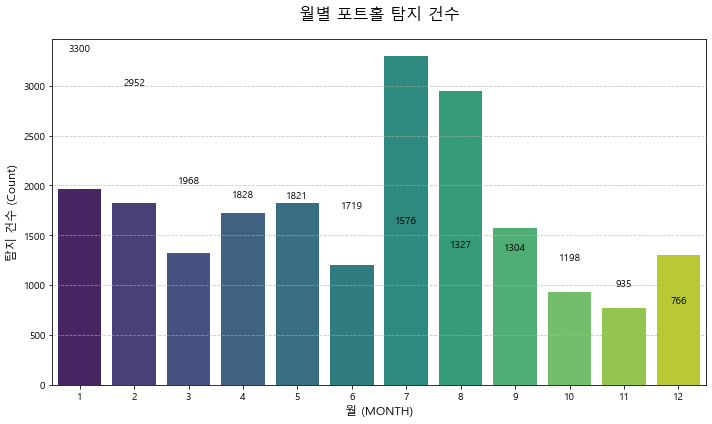

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. 데이터 준비 및 필터링
# ----------------------------------------------------------------------

# '파손종류' 컬럼에서 '포트홀'을 포함하는 행만 필터링합니다.
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# 'MONTH' 컬럼을 기준으로 월별 건수를 계산합니다.
monthly_counts = df_pothole['MONTH'].value_counts().reset_index()
monthly_counts.columns = ['MONTH', 'Count']

# 💡 문제 해결 핵심: 'MONTH'를 정수형으로 변환하여 새로운 컬럼에 저장합니다.
monthly_counts['MONTH_INT'] = monthly_counts['MONTH'].astype(int)

# 월 순서대로 정렬 (MONTH_INT 사용)
monthly_counts = monthly_counts.sort_values(by='MONTH_INT')

# ----------------------------------------------------------------------
# 2. 그래프 시각화 (Seaborn Bar Plot)
# ----------------------------------------------------------------------

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

sns.barplot(
    x='MONTH_INT',       # x축: 정수형 월
    y='Count',
    data=monthly_counts,
    palette='viridis'
)

# 그래프 제목 및 축 레이블 설정
plt.title('월별 포트홀 탐지 건수', fontsize=16, pad=20)
plt.xlabel('월 (MONTH)', fontsize=12)
plt.ylabel('탐지 건수 (Count)', fontsize=12)

# X축 눈금 설정 수정:
# 1. 눈금의 위치 (0, 1, 2...)는 정수형 월에서 1을 뺀 값으로 설정 (MONTH_INT - 1)
# 2. 눈금의 레이블 (1, 2, 3...)은 정수형 월 자체 (MONTH_INT)
plt.xticks(monthly_counts['MONTH_INT'] - 1, monthly_counts['MONTH_INT'])


# 각 막대 위에 실제 건수 값 표시
for index, row in monthly_counts.iterrows():
    plt.text(
        index,
        row['Count'] + 50,
        f"{row['Count']}",
        color='black',
        ha="center",
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

✅ 데이터 집계 완료. monthly_weekly_counts 변수가 정의되었습니다.


AttributeError: 'AxesSubplot' object has no attribute 'bar_label'

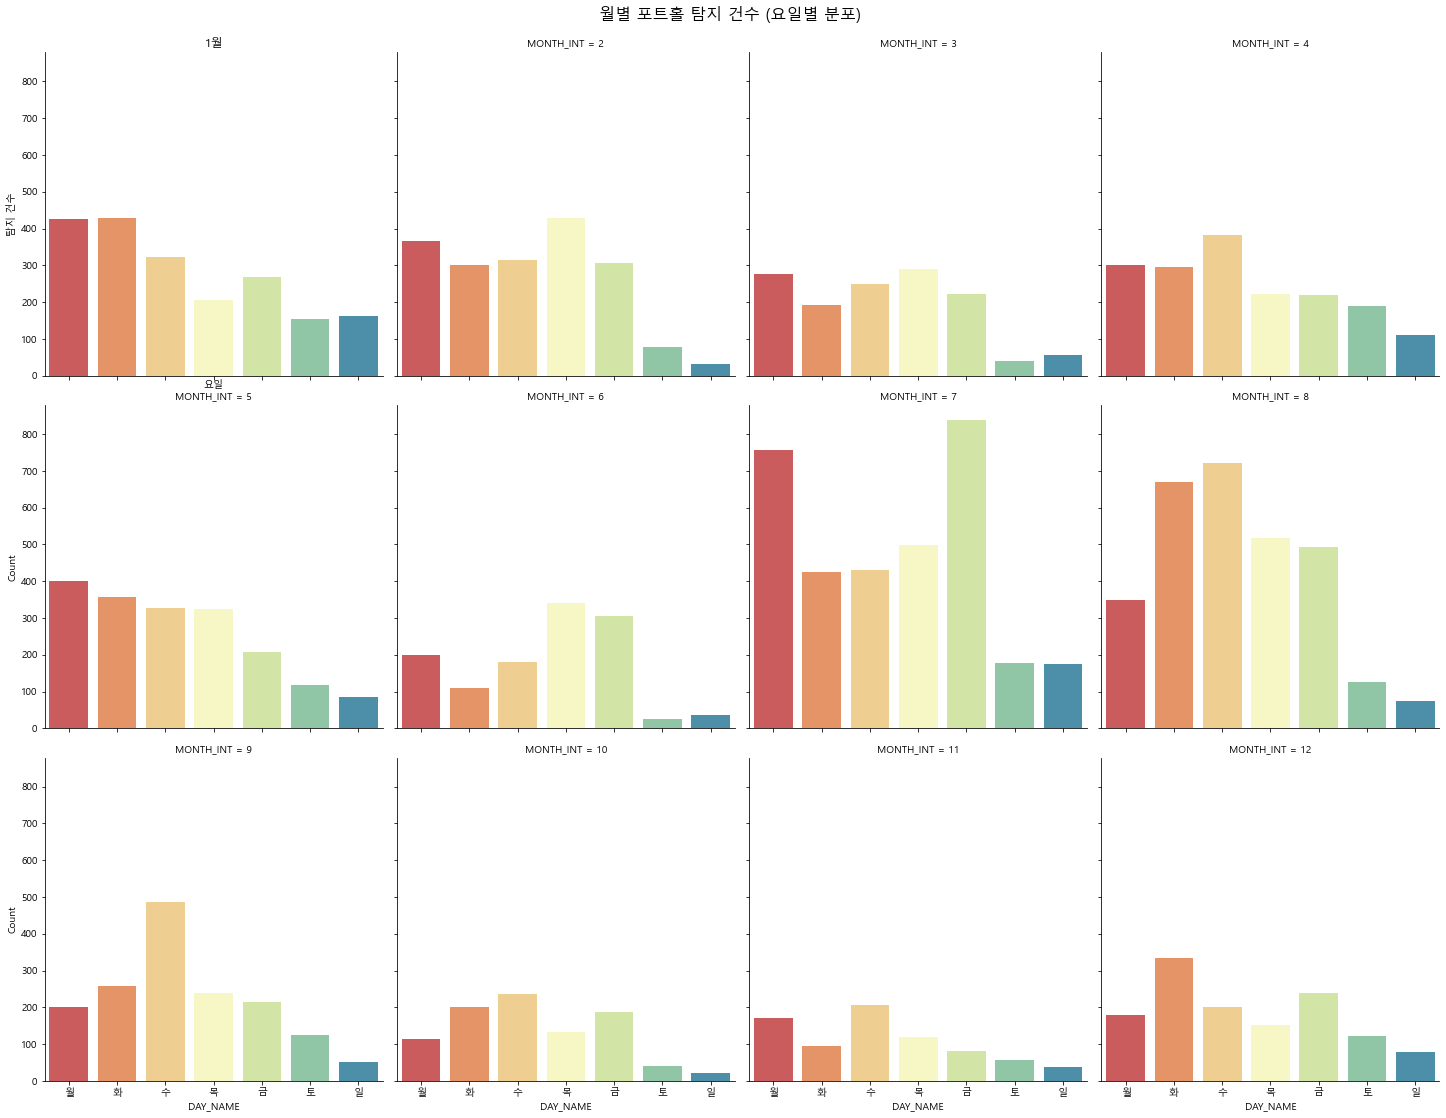

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. 데이터 준비 및 집계 (NameError 해결을 위해 반드시 필요)
# ----------------------------------------------------------------------

# df가 메모리에 로드되어 있고, '파손종류', 'MONTH', 'DAYOFWEEK' 컬럼이 있다고 가정합니다.

# '파손종류' 컬럼에서 '포트홀'을 포함하는 행만 필터링
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# 'MONTH' 컬럼을 정수형으로 변환
df_pothole['MONTH_INT'] = df_pothole['MONTH'].astype(int)

# DAYOFWEEK (0:월 ~ 6:일)을 한글 요일명으로 매핑
day_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df_pothole['DAY_NAME'] = df_pothole['DAYOFWEEK'].map(day_map)

# 월(MONTH_INT)과 요일명(DAY_NAME)으로 그룹화하여 건수(Count) 집계
# ⭐ 이 부분에서 monthly_weekly_counts 변수가 정의됩니다. ⭐
monthly_weekly_counts = df_pothole.groupby(['MONTH_INT', 'DAY_NAME']).size().reset_index(name='Count')

# 요일 순서 (월~일)를 지정하여 정렬
day_order = ['월', '화', '수', '목', '금', '토', '일']
monthly_weekly_counts['DAY_NAME'] = pd.Categorical(
    monthly_weekly_counts['DAY_NAME'], categories=day_order, ordered=True
)
monthly_weekly_counts = monthly_weekly_counts.sort_values(by=['MONTH_INT', 'DAY_NAME'])

print("✅ 데이터 집계 완료. monthly_weekly_counts 변수가 정의되었습니다.")

# ----------------------------------------------------------------------
# 2. 그래프 시각화 (Seaborn Catplot)
# ----------------------------------------------------------------------

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# FacetGrid를 이용해 월별로 그래프를 나누어 시각화
g = sns.catplot(
    data=monthly_weekly_counts, # ⭐ 이제 변수가 존재하므로 오류가 해결됩니다. ⭐
    x='DAY_NAME',
    y='Count',
    col='MONTH_INT',
    kind='bar',
    col_wrap=4,
    sharey=True,
    palette='Spectral'
)

# 제목 설정
g.fig.suptitle('월별 포트홀 탐지 건수 (요일별 분포)', fontsize=16, y=1.02)

# 각 서브플롯(월별 그래프) 설정
for ax in g.axes.flat:
    # x축 레이블 회전
    ax.tick_params(axis='x', labelrotation=0)
    # 제목 형식 변경
    title = ax.get_title()
    if 'MONTH_INT' in title:
        month_num = title.split('=')[1].strip()
        ax.set_title(f'{month_num}월')

    # x축과 y축 레이블 변경
    ax.set_xlabel("요일")
    ax.set_ylabel("탐지 건수")

    # 각 막대 위에 건수 표시
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

AttributeError: 'AxesSubplot' object has no attribute 'bar_label'

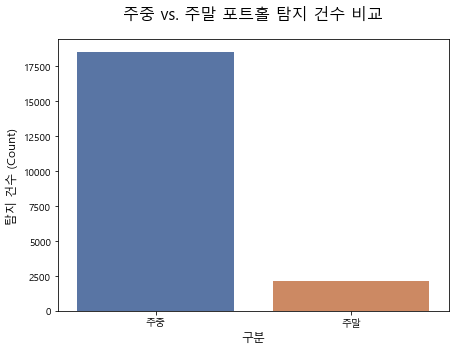

In [ ]:
# ----------------------------------------------------------------------
# 2. 그래프 시각화 (Seaborn Bar Plot)
# ----------------------------------------------------------------------

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))

# 막대 그래프 생성
ax = sns.barplot(
    x='Category',           # x축: 주중/주말
    y='Count',              # y축: 탐지 건수
    data=weekend_counts,
    palette=['#4c72b0', '#dd8452'] # 주중, 주말 색상 지정
)

# 그래프 제목 및 축 레이블 설정
plt.title('주중 vs. 주말 포트홀 탐지 건수 비교', fontsize=16, pad=20)
plt.xlabel('구분', fontsize=12)
plt.ylabel('탐지 건수 (Count)', fontsize=12)

# 각 막대 위에 실제 건수 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=12)

# Y축의 최대치를 약간 늘려 레이블 공간 확보
ax.set_ylim(0, weekend_counts['Count'].max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

AttributeError: 'AxesSubplot' object has no attribute 'bar_label'

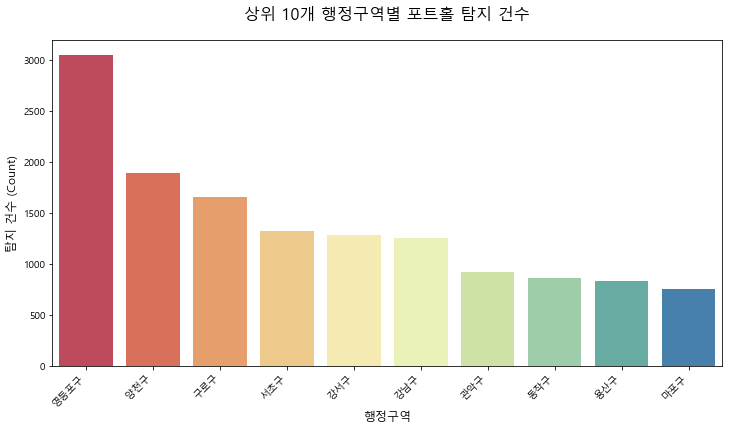

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. 데이터 준비 및 집계
# ----------------------------------------------------------------------

# '파손종류' 컬럼에서 '포트홀'을 포함하는 행만 필터링합니다.
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# '행정구역' 컬럼을 기준으로 건수를 계산합니다.
admin_area_counts = df_pothole['행정구역'].value_counts().reset_index()
admin_area_counts.columns = ['행정구역', 'Count']

# 건수(Count)가 많은 순서대로 내림차순 정렬합니다.
admin_area_counts = admin_area_counts.sort_values(by='Count', ascending=False)

# 탐지 건수가 적은 구역이 너무 많으면 그래프가 복잡해지므로,
# 상위 10개 구역만 시각화하는 것을 권장합니다. (필요에 따라 주석 처리 가능)
top_n = 10
admin_area_counts_top = admin_area_counts.head(top_n)

# ----------------------------------------------------------------------
# 2. 그래프 시각화 (Seaborn Bar Plot)
# ----------------------------------------------------------------------

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 건수가 많은 구역이 왼쪽에 오도록 막대 그래프를 그립니다.
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x='행정구역',           # x축: 행정구역
    y='Count',           # y축: 탐지 건수
    data=admin_area_counts_top, # 상위 N개 데이터 사용
    palette='Spectral'
)

# 그래프 제목 및 축 레이블 설정
plt.title(f'상위 {top_n}개 행정구역별 포트홀 탐지 건수', fontsize=16, pad=20)
plt.xlabel('행정구역', fontsize=12)
plt.ylabel('탐지 건수 (Count)', fontsize=12)

# X축 레이블이 겹치지 않도록 살짝 회전
plt.xticks(rotation=45, ha='right')

# 각 막대 위에 실제 건수 값 표시
for container in ax.containers:
    # ax.bar_label이 지원되지 않을 경우를 대비하여 ax.text 사용 가능
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=10)

# Y축의 최대치를 약간 늘려 레이블 공간 확보
ax.set_ylim(0, admin_area_counts_top['Count'].max() * 1.15)


plt.grid(axis='y', linestyle='--', alpha=0.7) # 수평 격자 라인 추가
plt.tight_layout() # 레이아웃 조정
plt.show()

In [ ]:
# 1) 포트홀만 필터링
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# 2) 교통량 관련 컬럼을 숫자로 변환 (중요!)
for col in ['speed', 'volume', 'occupancy']:
    df_pothole[col] = pd.to_numeric(df_pothole[col], errors='coerce')

# 3) 행정구역별 집계
admin_stats = (
    df_pothole.groupby("행정구역", as_index=False)
    .agg(
        pothole_count=("행정구역", "size"),
        mean_speed=("speed", "mean"),
        mean_volume=("volume", "mean"),
        mean_occupancy=("occupancy", "mean")
    )
)

C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\4060469607.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


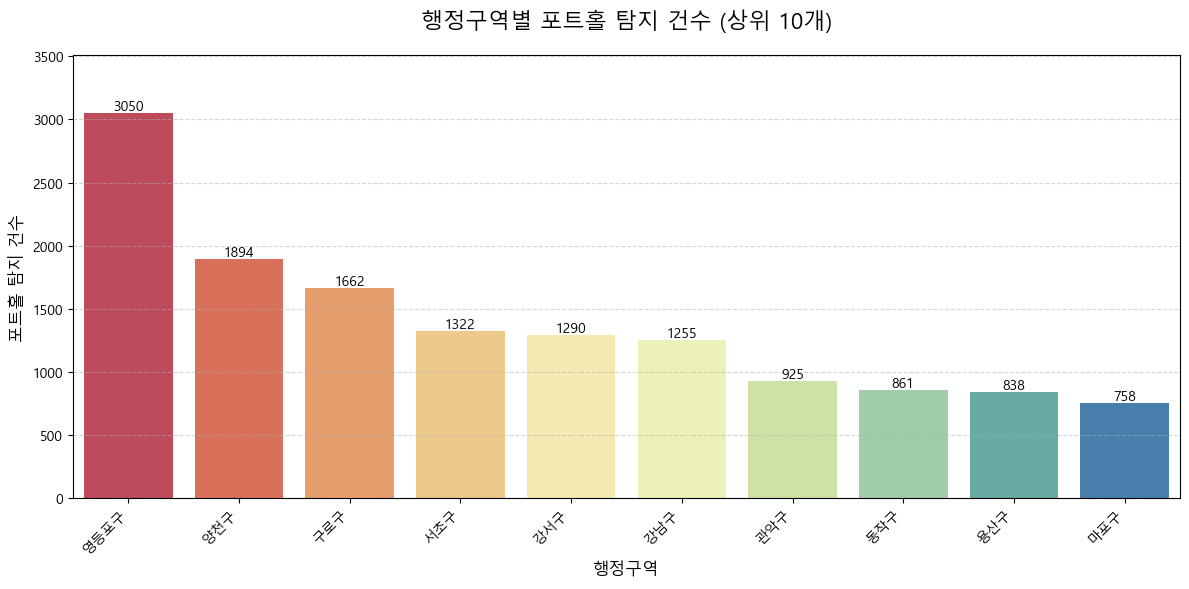

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상위 10개 구 추출
top_n = 10
admin_stats_top = admin_stats.sort_values("pothole_count", ascending=False).head(top_n)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=admin_stats_top,
    x="행정구역",
    y="pothole_count",
    palette="Spectral"
)

plt.title(f"행정구역별 포트홀 탐지 건수 (상위 {top_n}개)", fontsize=16, pad=20)
plt.xlabel("행정구역", fontsize=12)
plt.ylabel("포트홀 탐지 건수", fontsize=12)

# X축 레이블 기울이기
plt.xticks(rotation=45, ha="right")

# 막대 위에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type='edge', fontsize=10)

# y축 여유 공간 확보
ax.set_ylim(0, admin_stats_top["pothole_count"].max() * 1.15)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


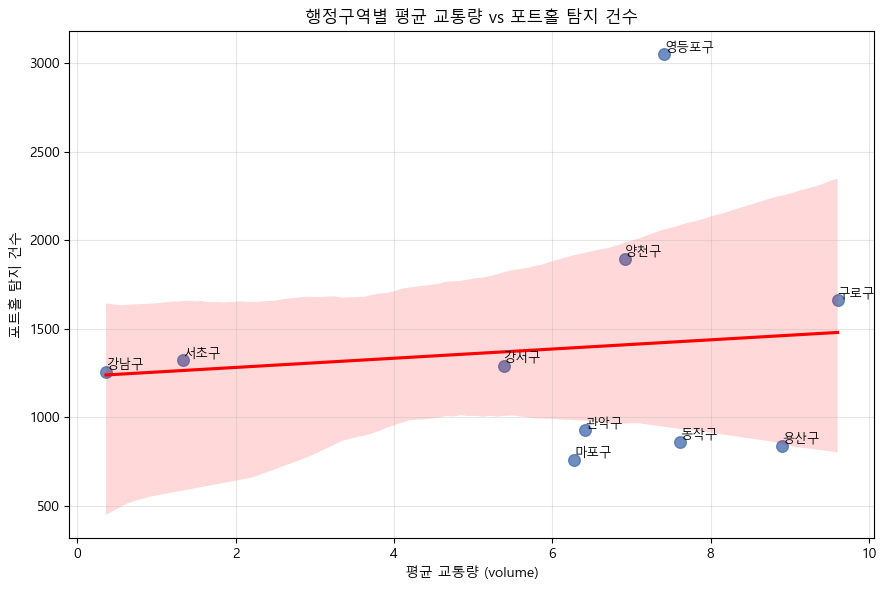

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상위 10개 행정구역만 선택
top_n = 10
top_areas = admin_stats.sort_values("pothole_count", ascending=False).head(top_n)

plt.figure(figsize=(9, 6))

ax = sns.regplot(
    data=top_areas,
    x="mean_volume",
    y="pothole_count",
    scatter_kws={"s": 70, "color": "#4C72B0"},
    line_kws={"color": "red"}
)

# 라벨 붙이기
for _, row in top_areas.iterrows():
    ax.text(
        row["mean_volume"],
        row["pothole_count"],
        row["행정구역"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("행정구역별 평균 교통량 vs 포트홀 탐지 건수")
plt.xlabel("평균 교통량 (volume)")
plt.ylabel("포트홀 탐지 건수")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


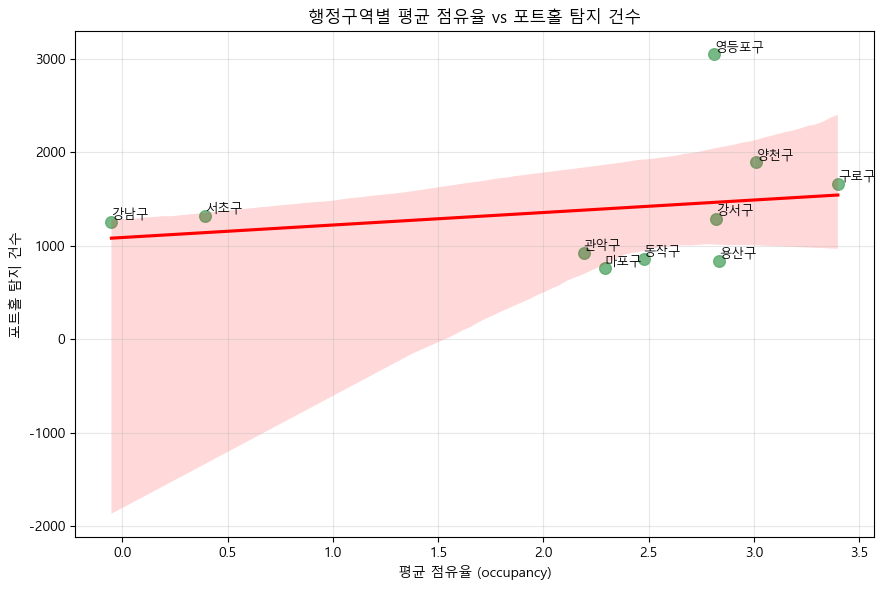

In [ ]:
plt.figure(figsize=(9, 6))

ax = sns.regplot(
    data=top_areas,
    x="mean_occupancy",
    y="pothole_count",
    scatter_kws={"s": 70, "color": "#55A868"},
    line_kws={"color": "red"}
)

# 라벨 붙이기
for _, row in top_areas.iterrows():
    ax.text(
        row["mean_occupancy"],
        row["pothole_count"],
        row["행정구역"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("행정구역별 평균 점유율 vs 포트홀 탐지 건수")
plt.xlabel("평균 점유율 (occupancy)")
plt.ylabel("포트홀 탐지 건수")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 공통 준비
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 포트홀만 필터
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

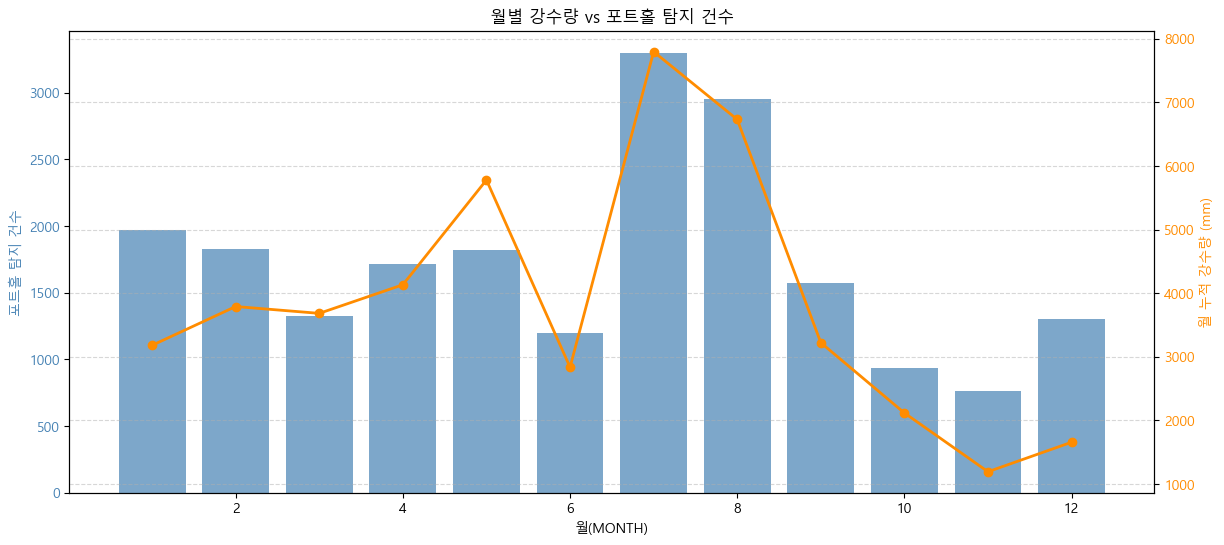

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1) 월별 포트홀 탐지 건수 집계
# -------------------------
df_pothole = df[df["파손종류"].str.contains("포트홀", na=False, case=False)]
monthly_pothole = df_pothole.groupby("MONTH")["파손종류"].count().reset_index()
monthly_pothole.columns = ["MONTH", "pothole_count"]

# -------------------------
# 2) 월별 강수량 집계 (합계 또는 평균 선택 가능 → 보통 합계 사용)
# -------------------------
monthly_rain = df.groupby("MONTH")["RN_DAY"].sum().reset_index()
monthly_rain.columns = ["MONTH", "rain_sum"]

# -------------------------
# 3) 두 데이터를 MONTH 기준으로 merge
# -------------------------
df_month = pd.merge(monthly_pothole, monthly_rain, on="MONTH")

# -------------------------
# 4) 정확한 그래프 생성
# -------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

# 포트홀 탐지 건수 (Bar)
ax1.bar(df_month["MONTH"], df_month["pothole_count"],
        color="steelblue", alpha=0.7, label="포트홀 탐지 건수")

ax1.set_xlabel("월(MONTH)")
ax1.set_ylabel("포트홀 탐지 건수", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# 강수량 (Line, 오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(df_month["MONTH"], df_month["rain_sum"],
         color="darkorange", marker="o", linewidth=2, label="월 누적 강수량")

ax2.set_ylabel("월 누적 강수량 (mm)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("월별 강수량 vs 포트홀 탐지 건수")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

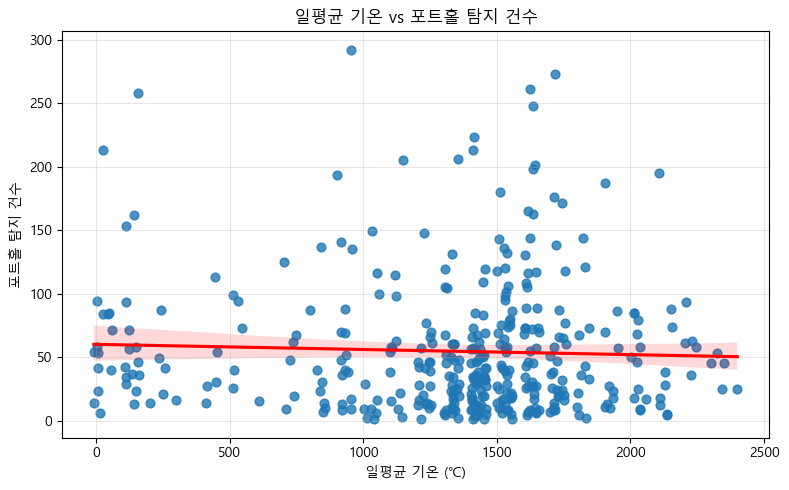

In [ ]:
# 일별 포트홀 수 + 기온 평균
daily_temp = (
    df_pothole.groupby('DATE', as_index=False)
    .agg(pothole_count=('등록번호', 'size'))
    .merge(
        df.groupby('DATE', as_index=False).agg(
            TA_AVG=('TA_AVG', 'mean'),
            TA_MIN=('TA_MIN', 'mean')
        ),
        on='DATE', how='left'
    )
)

plt.figure(figsize=(8, 5))
sns.regplot(data=daily_temp, x='TA_AVG', y='pothole_count',
            scatter_kws={'s': 40}, line_kws={'color': 'red'})
plt.title('일평균 기온 vs 포트홀 탐지 건수')
plt.xlabel('일평균 기온 (℃)')
plt.ylabel('포트홀 탐지 건수')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) 포트홀만 필터
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# 2) 타입 정리 (혹시 문자형이면 숫자로 변환)
for col in ['HM_AVG', 'SD_DAY', 'SD_NEW', 'SD_MAX']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3) 일별 포트홀 건수 + 기상 정보 묶기
daily_pothole = (
    df_pothole.groupby('DATE', as_index=False)
    .agg(pothole_count=('등록번호', 'size'))
)

daily_weather = (
    df.groupby('DATE', as_index=False)
    .agg(
        HM_AVG=('HM_AVG', 'mean'),
        SD_DAY=('SD_DAY', 'mean'),
        SD_NEW=('SD_NEW', 'mean'),
        SD_MAX=('SD_MAX', 'mean')
    )
)

daily = daily_pothole.merge(daily_weather, on='DATE', how='left')

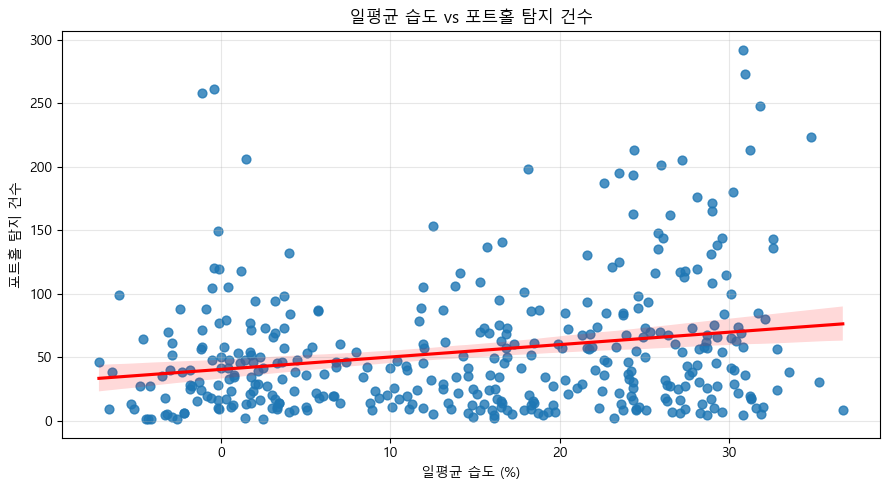

In [ ]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=daily,
    x='HM_AVG',
    y='pothole_count',
    scatter_kws={'s': 40},
    line_kws={'color': 'red'}
)

plt.title('일평균 습도 vs 포트홀 탐지 건수')
plt.xlabel('일평균 습도 (%)')
plt.ylabel('포트홀 탐지 건수')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\hyebi\AppData\Local\Temp\ipykernel_18652\2321141284.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


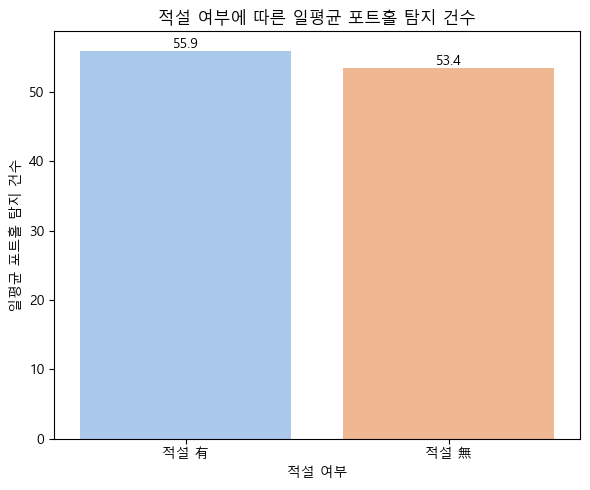

In [ ]:
# 눈 온 날 여부 플래그
daily['snow_flag'] = (
    (daily['SD_DAY'] > 0) |
    (daily['SD_NEW'] > 0) |
    (daily['SD_MAX'] > 0)
)

daily['snow_flag'] = daily['snow_flag'].map({True: '적설 有', False: '적설 無'})

snow_stats = (
    daily.groupby('snow_flag', as_index=False)
    .agg(
        mean_pothole=('pothole_count', 'mean'),
        days=('DATE', 'size')
    )
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=snow_stats,
    x='snow_flag',
    y='mean_pothole',
    palette='pastel'
)
plt.title('적설 여부에 따른 일평균 포트홀 탐지 건수')
plt.xlabel('적설 여부')
plt.ylabel('일평균 포트홀 탐지 건수')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', label_type='edge')

plt.tight_layout()
plt.show()

In [ ]:
import folium
import json
from folium.features import DivIcon
from folium.plugins import MarkerCluster

# --- 1) 포트홀 필터링 ---
df_pothole = df[df['파손종류'].str.contains('포트홀', na=False, case=False)].copy()

# --- 2) 지도 중심 ---
center_lat = df_pothole["위도"].mean()
center_lon = df_pothole["경도"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

# --- 3) 서울 구 경계 GeoJSON 불러오기 ---
geo_path = "seoul_municipalities_geo.json"
with open(geo_path, encoding="utf-8") as f:
    geo_json = json.load(f)

# --- 4) 경계 스타일 + 항상 표시되도록 ---
folium.GeoJson(
    geo_json,
    name="Seoul Districts",
    style_function=lambda x: {
        "fillColor": "#00000000",  # 투명
        "color": "#1f77b4",        # 파란색 경계
        "weight": 2,
        "fillOpacity": 0,
    }
).add_to(m)

# --- 5) 폴리곤 안에 행정구역 라벨 표시 ---
for feature in geo_json["features"]:
    gu_name = feature["properties"]["name"]
    coords = feature["geometry"]["coordinates"][0]

    # 폴리곤 중심 계산 (centroid)
    lon_list = [pt[0] for pt in coords]
    lat_list = [pt[1] for pt in coords]
    center = [sum(lat_list)/len(lat_list), sum(lon_list)/len(lon_list)]

    # 지도 텍스트 추가
    folium.map.Marker(
        location=center,
        icon=DivIcon(
            icon_size=(150, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size:15px; color:#0047ab;"><b>{gu_name}</b></div>'
        )
    ).add_to(m)

# --- 6) 포트홀 클러스터 표시 ---
cluster = MarkerCluster().add_to(m)

for _, row in df_pothole.iterrows():
    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=3,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.8,
        popup=f"{row['행정구역']} / {row['노선']} / {row['등록번호']}"
    ).add_to(cluster)

# --- 7) 저장 ---
m.save("pothole_map_with_districts.html")
print("pothole_map_with_districts.html 생성 완료")

pothole_map_with_districts.html 생성 완료


## 파생 변수 생성

In [ ]:
df = pd.read_csv("/포트홀위치_data_weather_traffic.csv")
df.head()

,dataId,vhcleLat,vhcleLot,regDt,YEAR,MONTH,DAY,DATE,TA_AVG,TA_MAX,...,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_index,vdsId,speed,volume,occupancy
0,PVDL-IDV1257027100-1728373902-4268,37.600386,127.103113,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,24,0010VDE25900,-1.0,-1,-1.00
1,PVDL-IDV1257027230-1728377705-425,37.562897,127.175430,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,48,0010VDS25450,118.0,7,2.55
2,PVDL-IDV1257027690-1728375894-2246,37.509533,127.061624,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,120,0301VDE04700,100.0,0,0.00
3,PVDL-IDV1257027700-1728366712-11421,37.534262,127.137750,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,48,0010VDS25450,118.0,7,2.55
4,PVDL-IDV1257027880-1728375382-2758,37.595760,127.083124,2024-10-08 09:02:24+00:00,2024,10,8,2024-10-08,1945,17.7,...,-9.0,-9.0,22.0,6.8,2248,61,0010VDS26000,-1.0,-1,-1.00


In [ ]:
df2 = pd.read_excel("/content/보수위치_data_weather_traffic.xlsx")
df2.head()

,Unnamed: 0,등록번호,처리상태,관할기관,행정구역,노선,방향,지번주소,도로명주소,파손종류,...,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_index,nearest_vdsId,speed,volume,occupancy
0,0,20240108165734000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-17,성북구 한천로101길 66,포트홀,...,-9.0,-9.0,-1.1,8.3,913,61,0010VDS26000,-1.0,-1,-1.0
1,1,20240108165727000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 301-18,성북구 한천로101길 66,포트홀,...,-9.0,-9.0,-1.1,8.3,913,61,0010VDS26000,-1.0,-1,-1.0
2,2,20240108165718000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,...,-9.0,-9.0,-1.1,8.3,913,61,0010VDS26000,-1.0,-1,-1.0
3,3,20240108165711000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),NaN,성북구 한천로101길 66,포트홀,...,-9.0,-9.0,-1.1,8.3,913,61,0010VDS26000,-1.0,-1,-1.0
4,4,20240108165701000,보수,북부,성북구,미아~상계선,노원천주교회 (상계8동주공10단지),성북구 장위동 311-16,성북구 한천로101길 66,포트홀,...,-9.0,-9.0,-1.1,8.3,913,61,0010VDS26000,-1.0,-1,-1.0


In [ ]:
print(f"df 컬럼: {df.columns}")
print(f"df2 컬럼: {df2.columns}")

df 컬럼: Index(['dataId', 'vhcleLat', 'vhcleLot', 'regDt', 'YEAR', 'MONTH', 'DAY',
       'DATE', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99',
       'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY',
       'nearest_vds_index', 'vdsId', 'speed', 'volume', 'occupancy'],
      dtype='object')
df2 컬럼: Index(['Unnamed: 0', '등록번호', '처리상태', '관할기관', '행정구역', '노선', '방향', '지번주소',
       '도로명주소', '파손종류', '위도', '경도', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG',
       'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW',
       'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index',
       'nearest_vdsId', 'speed', 'volume', 'occupancy'],
      dtype='object')


In [ ]:
from scipy.spatial import cKDTree

df_new = df.copy()
df2_new = df2.copy()

df_new = df_new.rename(columns={'vhcleLat': 'Lat', 'vhcleLot': 'Lon'})
df2_new = df2_new.rename(columns={'위도': 'Lat', '경도': 'Lon'})

#  df2의 위치 정보를 기반으로 df에 관할기관/행정구역 채워넣기
tree = cKDTree(df2_new[['Lat', 'Lon']])

dist, idx = tree.query(df_new[['Lat', 'Lon']], k=1)

df_new['관할기관'] = df2_new.iloc[idx]['관할기관'].values
df_new['행정구역'] = df2_new.iloc[idx]['행정구역'].values

common_cols = df_new.columns.intersection(df2_new.columns)

df_new = df_new[common_cols]
df2_new = df2_new[common_cols]

print(f"남은 공통 컬럼 개수: {len(common_cols)}")
print(f"최종 컬럼 목록: {common_cols.tolist()}")

남은 공통 컬럼 개수: 24
최종 컬럼 목록: ['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed', 'volume', 'occupancy', '관할기관', '행정구역']


In [ ]:
print(df_new.shape)
print(df2_new.shape)

print(f"df 컬럼: {df_new.columns}")
print(f"df2 컬럼: {df2_new.columns}")

(1000, 24)
(20694, 24)
df 컬럼: Index(['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG', 'TA_MAX',
       'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX',
       'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed', 'volume',
       'occupancy', '관할기관', '행정구역'],
      dtype='object')
df2 컬럼: Index(['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG', 'TA_MAX',
       'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX',
       'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed', 'volume',
       'occupancy', '관할기관', '행정구역'],
      dtype='object')


### 날짜 데이터 활용 파생변수

In [ ]:
df_feat = df_new.copy()
df2_feat = df2_new.copy()

def create_date_features(data, target_date_str='2025-12-07'):
    """
    날짜 정보를 활용해 파생변수를 생성하는 함수
    target_date_str: 경과일수 계산을 위한 기준 시점 (2025-12-07)
    """
    data = data.copy()

    if data['DATE'].dtype == 'object':
        data['DATE'] = pd.to_datetime(data['DATE'])

    target_date = pd.to_datetime(target_date_str)

    # 1. 계절 및 기후 관련
    season_map = {
        3:'Spring', 4:'Spring', 5:'Spring',
        6:'Summer', 7:'Summer', 8:'Summer',
        9:'Fall', 10:'Fall', 11:'Fall',
        12:'Winter', 1:'Winter', 2:'Winter'
    }
    data['Season'] = data['MONTH'].map(season_map)
    data['Is_Thaw'] = data['MONTH'].apply(lambda x: 1 if x in [2, 3] else 0)
    data['Is_RainySeason'] = data['MONTH'].apply(lambda x: 1 if x in [6, 7] else 0)

    # 2. 교통 패턴 관련 (요일/주말)
    data['Day_of_Week'] = data['DATE'].dt.weekday
    data['Is_Weekend'] = data['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

    # 3. 시계열 추세 (Days_Elapsed) - 2025-12-07 기준 역산
    data['Days_Elapsed'] = (target_date - data['DATE']).dt.days

    return data

df_feat = create_date_features(df_feat, target_date_str='2025-12-07')
df2_feat = create_date_features(df2_feat, target_date_str='2025-12-07')

cols_to_check = ['DATE', 'Season', 'Is_Thaw', 'Is_Weekend', 'Days_Elapsed']

print(f"--- df_feat (예측용) 확인 ---\n{df_feat[cols_to_check].head(3)}")
print(f"\n--- df2_feat (학습용) 확인 ---\n{df2_feat[cols_to_check].head(3)}")

--- df_feat (예측용) 확인 ---
        DATE Season  Is_Thaw  Is_Weekend  Days_Elapsed
0 2024-10-08   Fall        0           0           425
1 2024-10-08   Fall        0           0           425
2 2024-10-08   Fall        0           0           425

--- df2_feat (학습용) 확인 ---
        DATE  Season  Is_Thaw  Is_Weekend  Days_Elapsed
0 2024-01-08  Winter        0           0           699
1 2024-01-08  Winter        0           0           699
2 2024-01-08  Winter        0           0           699


### 날씨데이터 활용 파생변수

In [ ]:
df_feat2 = df_feat.copy()
df2_feat2 = df2_feat.copy()

def create_weather_features(data):
    """
    기상 데이터를 활용해 도로 파손 관련 파생변수 3가지를 생성하는 함수
    (1.일교차, 2.동결융해, 3.강우강도)
    """
    data = data.copy()

    # 1. 일교차 (Temp_Range)
    data['Temp_Range'] = data['TA_MAX'] - data['TA_MIN']

    # 2. 동결융해 (Is_Freeze_Thaw)
    data['Is_Freeze_Thaw'] = np.where((data['TA_MIN'] < 0) & (data['TA_MAX'] > 0), 1, 0)

    # 3. 강우 강도 (Rain_Intensity)
    data['Rain_Intensity'] = np.where(data['RN_DUR'] > 0,
                                      data['RN_DAY'] / data['RN_DUR'],
                                      0)

    return data

df_feat2 = create_weather_features(df_feat2)
df2_feat2 = create_weather_features(df2_feat2)

# 결과 확인
cols_to_check = ['TA_MAX', 'TA_MIN', 'Temp_Range', 'Is_Freeze_Thaw', 'RN_DAY', 'RN_DUR', 'Rain_Intensity']

print("\n--- df_feat2 (예측용) 결과 확인 ---")
print(df_feat2[cols_to_check].head())

print("\n--- df2_feat2 (학습용) 결과 확인 ---")
print(df2_feat2[cols_to_check].head())


--- df_feat2 (예측용) 결과 확인 ---
   TA_MAX  TA_MIN  Temp_Range  Is_Freeze_Thaw  RN_DAY  RN_DUR  Rain_Intensity
0    17.7    1505     -1487.3               0    2.57    -9.0             0.0
1    17.7    1505     -1487.3               0    2.57    -9.0             0.0
2    17.7    1505     -1487.3               0    2.57    -9.0             0.0
3    17.7    1505     -1487.3               0    2.57    -9.0             0.0
4    17.7    1505     -1487.3               0    2.57    -9.0             0.0

--- df2_feat2 (학습용) 결과 확인 ---
   TA_MAX  TA_MIN  Temp_Range  Is_Freeze_Thaw  RN_DAY  RN_DUR  Rain_Intensity
0    -4.7    1441     -1445.7               0    2.06    -9.0             0.0
1    -4.7    1441     -1445.7               0    2.06    -9.0             0.0
2    -4.7    1441     -1445.7               0    2.06    -9.0             0.0
3    -4.7    1441     -1445.7               0    2.06    -9.0             0.0
4    -4.7    1441     -1445.7               0    2.06    -9.0             0.0


### 교통량 데이터 활용 파생변수

In [ ]:
df_feat3 = df_feat2.copy()
df2_feat3 = df2_feat2.copy()

def create_traffic_features(data):
    """
    교통 데이터를 활용해 도로 파손에 영향을 주는 파생변수 생성
    (1.혼잡도, 2.대형차량부하, 3.저속정체여부)
    """
    data = data.copy()

    # 1. 혼잡도 지수 (Congestion_Index)
    data['Congestion_Index'] = np.where(data['speed'] > 0,
                                        data['volume'] / data['speed'],
                                        0)

    # 2. 대형차량/부하 지표 (Load_Index) - 차량 1대당 평균 점유율
    data['Load_Index'] = np.where(data['volume'] > 0,
                                  data['occupancy'] / data['volume'],
                                  0)

    # 3. 저속 정체 여부 (Is_Congested)
    data['Is_Congested'] = np.where(data['speed'] < 40, 1, 0)

    return data


df_feat3 = create_traffic_features(df_feat3)
df2_feat3 = create_traffic_features(df2_feat3)

# 결과 확인
cols_to_check = ['speed', 'volume', 'occupancy', 'Congestion_Index', 'Load_Index', 'Is_Congested']

print("\n--- df_feat3 (예측용) 결과 확인 ---")
print(df_feat3[cols_to_check].head())

print("\n--- df2_feat3 (학습용) 결과 확인 ---")
print(df2_feat3[cols_to_check].head())


--- df_feat3 (예측용) 결과 확인 ---
   speed  volume  occupancy  Congestion_Index  Load_Index  Is_Congested
0   -1.0      -1      -1.00          0.000000    0.000000             1
1  118.0       7       2.55          0.059322    0.364286             0
2  100.0       0       0.00          0.000000    0.000000             0
3  118.0       7       2.55          0.059322    0.364286             0
4   -1.0      -1      -1.00          0.000000    0.000000             1

--- df2_feat3 (학습용) 결과 확인 ---
   speed  volume  occupancy  Congestion_Index  Load_Index  Is_Congested
0   -1.0      -1       -1.0               0.0         0.0             1
1   -1.0      -1       -1.0               0.0         0.0             1
2   -1.0      -1       -1.0               0.0         0.0             1
3   -1.0      -1       -1.0               0.0         0.0             1
4   -1.0      -1       -1.0               0.0         0.0             1


In [ ]:
df_feat3['Is_Congested'].value_counts()

,count
Is_Congested,
0,855
1,145


## 파생 변수 상관관계 분석

In [ ]:
df_feat3 = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/산업빅데이터/포트홀위치_data.xlsx")
df2_feat3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/산업빅데이터/보수위치_data.csv")

In [ ]:
print("포트홀 위치 데이터 : ",df_feat3.columns)
print("보수 위치 데이터 : ",df2_feat3.columns)

포트홀 위치 데이터 :  Index(['Unnamed: 0', 'Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG',
       'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW',
       'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed',
       'volume', 'occupancy', '관할기관', '행정구역', 'Season', 'Is_Thaw',
       'Is_RainySeason', 'Day_of_Week', 'Is_Weekend', 'Days_Elapsed',
       'Temp_Range', 'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index',
       'Load_Index', 'Is_Congested'],
      dtype='object')
보수 위치 데이터 :  Index(['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG', 'TA_MAX',
       'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX',
       'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed', 'volume',
       'occupancy', '관할기관', '행정구역', 'Season', 'Is_Thaw', 'Is_RainySeason',
       'Day_of_Week', 'Is_Weekend', 'Days_Elapsed', 'Temp_Range',
       'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index', 'Load_Index',
       'Is_Congested'],

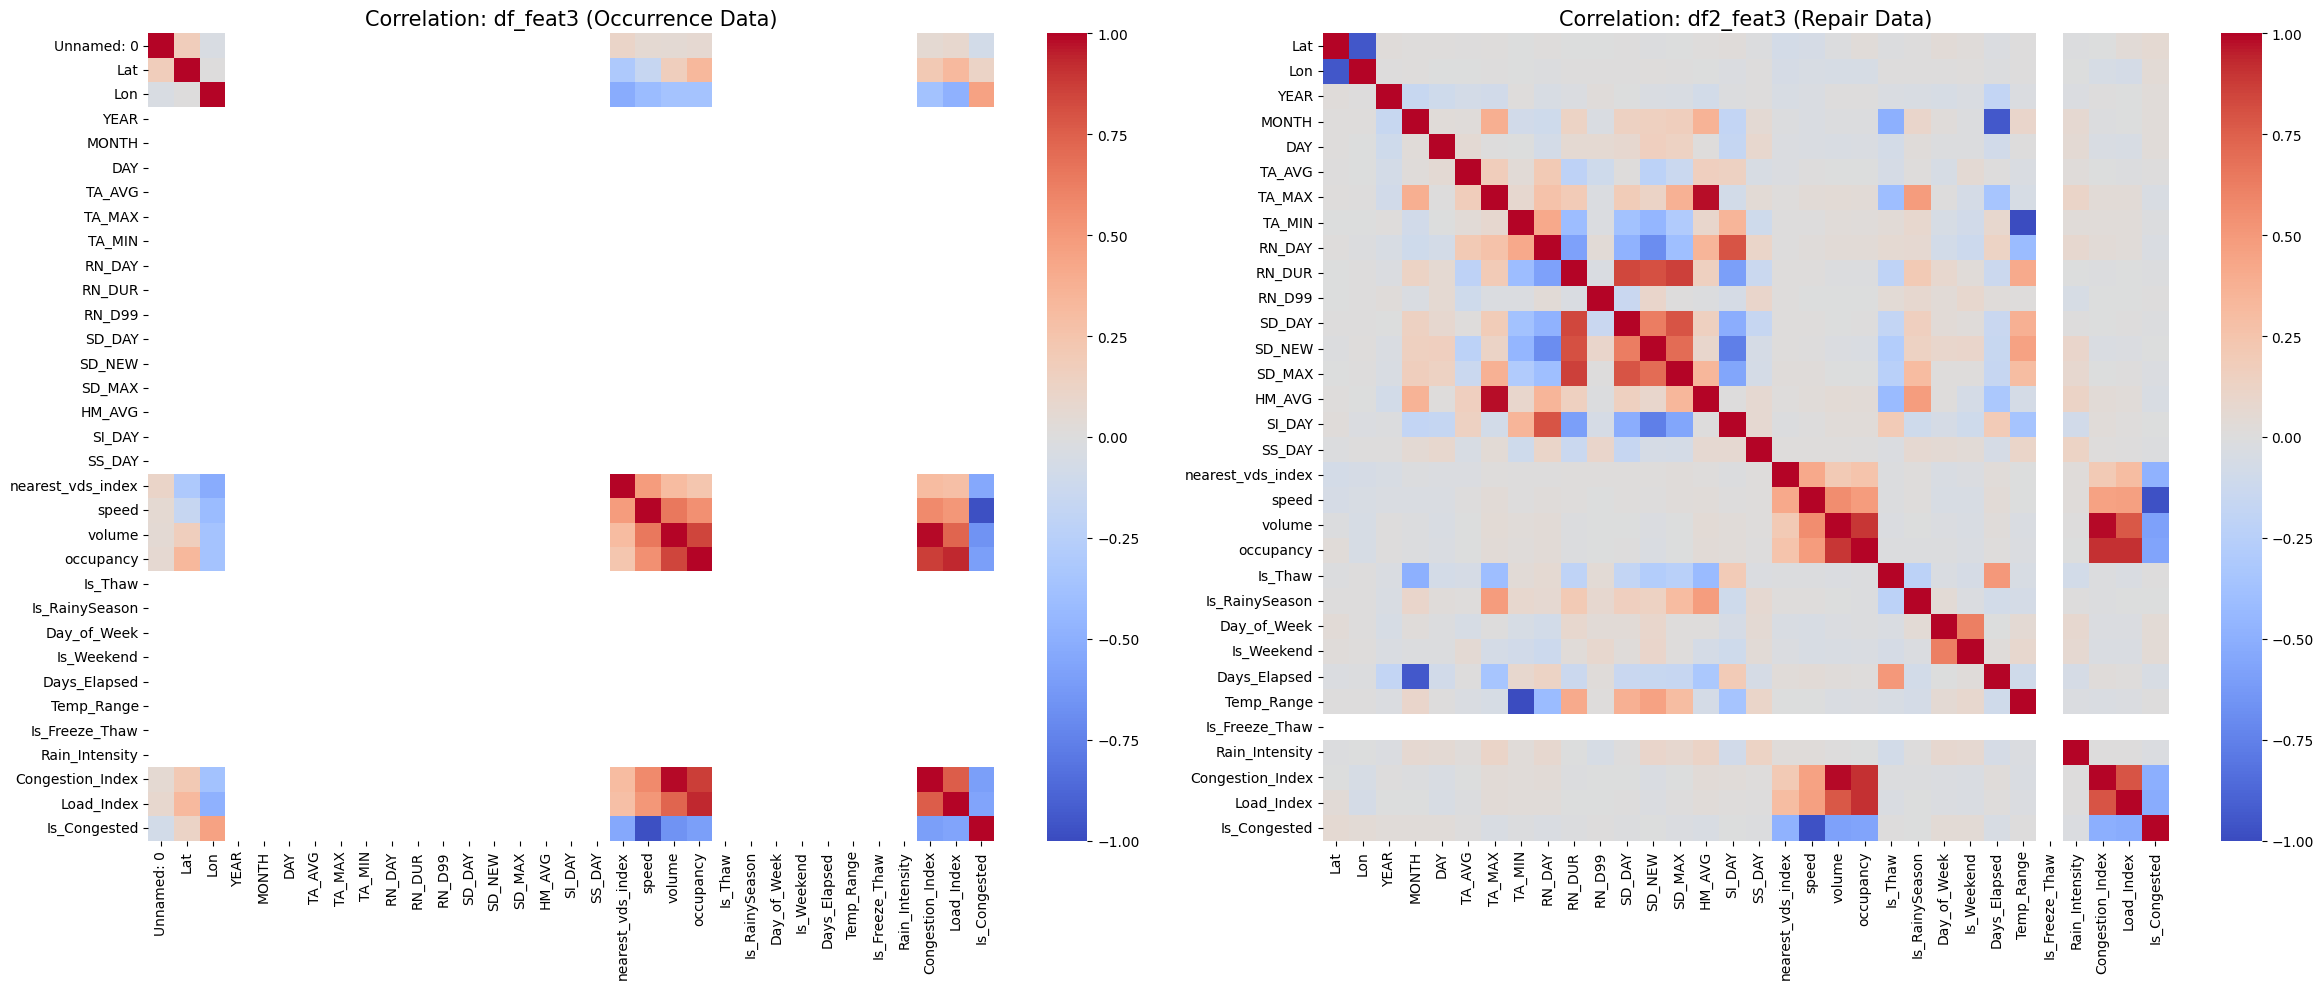

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 수치형 컬럼만 선택 (날짜, 지역명 등 제외)
# 상관계수는 숫자끼리만 계산 가능합니다.
df_numeric = df_feat3.select_dtypes(include=['number'])
df2_numeric = df2_feat3.select_dtypes(include=['number'])

# 2. 상관계수 행렬 계산 (Pearson Correlation)
corr_matrix_df = df_numeric.corr()
corr_matrix_df2 = df2_numeric.corr()

# 3. 시각화 (두 데이터프레임 비교)
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# (1) df_feat3 (발생 데이터) 상관관계
sns.heatmap(corr_matrix_df, ax=axes[0], annot=False, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Correlation: df_feat3 (Occurrence Data)', fontsize=15)

# (2) df2_feat3 (보수 데이터) 상관관계
sns.heatmap(corr_matrix_df2, ax=axes[1], annot=False, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Correlation: df2_feat3 (Repair Data)', fontsize=15)

plt.tight_layout()
plt.show()

🔴 빨간선: 같이 증가하는 관계 (양의 상관관계)
🔵 파란선: 반대로 움직이는 관계 (음의 상관관계)


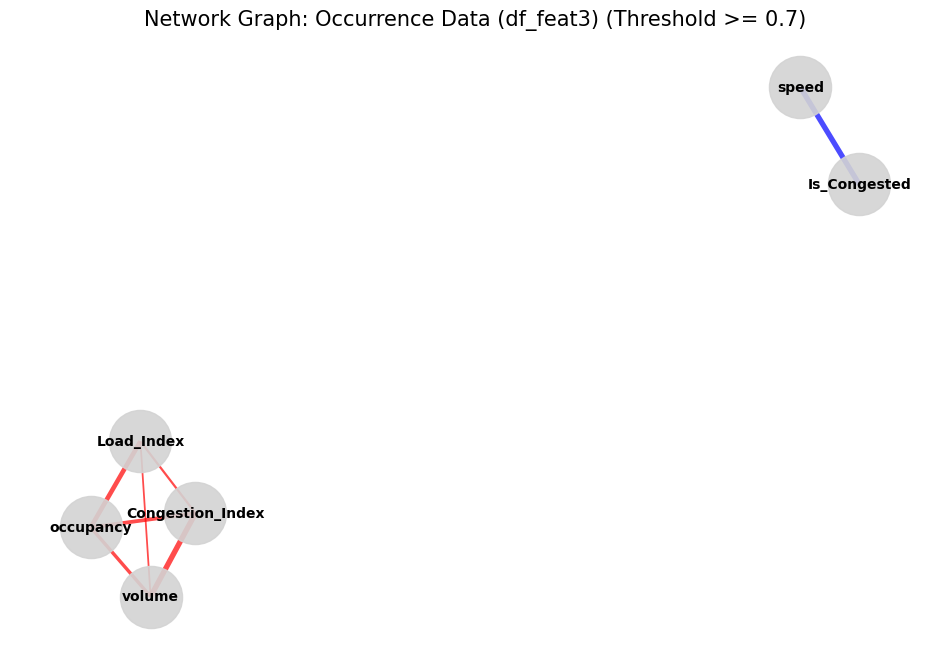

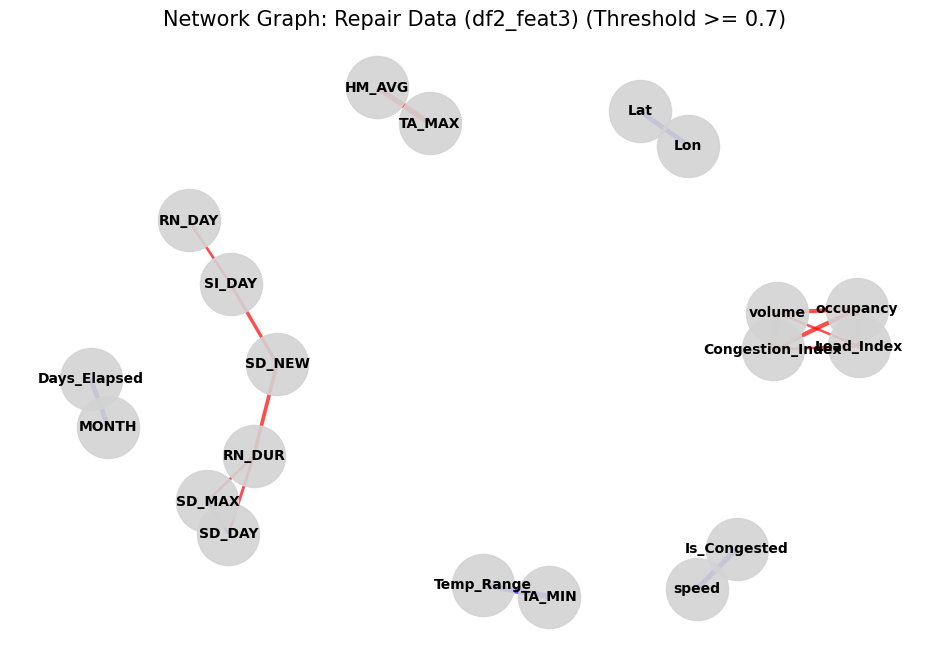

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. 수치형 데이터 준비
df_numeric = df_feat3.select_dtypes(include=['number'])
df2_numeric = df2_feat3.select_dtypes(include=['number'])

def draw_network_graph(df, title, threshold=0.7):
    # 상관계수 계산
    corr_matrix = df.corr()

    # 그래프 객체 생성
    G = nx.Graph()

    # 엣지(선) 추가 로직
    edges = []
    edge_colors = []
    edge_weights = []

    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            corr_val = corr_matrix.iloc[i, j]

            # 임계값(0.7)을 넘는 강한 관계만 연결
            if abs(corr_val) >= threshold:
                G.add_edge(cols[i], cols[j])

                # 색상: 양수면 빨강, 음수면 파랑
                if corr_val > 0:
                    edge_colors.append('red')
                else:
                    edge_colors.append('blue')

                # 굵기: 상관계수가 높을수록 굵게 (기본값 + 가중치)
                edge_weights.append(1 + (abs(corr_val) - threshold) * 10)

    # 시각화 설정
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42, k=0.5) # k는 노드 간 거리 조절

    # 노드 그리기
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgray', alpha=0.9)

    # 엣지 그리기
    nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.7)

    # 라벨(글자) 그리기
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold')

    plt.title(f"{title} (Threshold >= {threshold})", fontsize=15)
    plt.axis('off') # 축 제거
    plt.show()

# --- 실행 ---

print("🔴 빨간선: 같이 증가하는 관계 (양의 상관관계)")
print("🔵 파란선: 반대로 움직이는 관계 (음의 상관관계)")

# 1. df_feat3 (발생 데이터)
draw_network_graph(df_numeric, "Network Graph: Occurrence Data (df_feat3)")

# 2. df2_feat3 (보수 데이터)
draw_network_graph(df2_numeric, "Network Graph: Repair Data (df2_feat3)")

## 미발생 데이터 및 타겟값 추가

In [ ]:
import pandas as pd
import numpy as np
import requests
import json
from pyproj import Transformer
from scipy.spatial import cKDTree

df_feat3 = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/산업빅데이터/포트홀위치_data.xlsx")
df2_feat3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/산업빅데이터/보수위치_data.csv")

In [ ]:
import pandas as pd
import numpy as np
import requests
import json
from pyproj import Transformer
from scipy.spatial import cKDTree

# 1. 원본 데이터 불러오기
print("📂 1. 데이터 불러오기...")

path = "/content/drive/MyDrive/Colab Notebooks/산업빅데이터/보수위치_data.csv"

try:
    df2_feat3 = pd.read_csv(path)
except Exception as e:
    print(f"⚠️ 파일 로드 실패 (경로 확인 필요): {e}")

# 날짜 변환
df2_feat3['DATE'] = pd.to_datetime(df2_feat3['DATE'])
print(f"   -> 원본 데이터 개수: {len(df2_feat3)}개")

# 2. 미발생 데이터(Negative Sampling) 생성
print("🚀 2. 미발생 데이터 생성 (날짜/위치 변경)...")

df_pos = df2_feat3.copy()
df_pos['target'] = 1

negative_ratio = 2  # 1:2 비율
neg_list = []

np.random.seed(42) # 재현성을 위해 시드 고정

for i in range(negative_ratio):
    temp_neg = df_pos.copy()
    temp_neg['target'] = 0

    # (1) 위치 변경 (약 200m 내외 노이즈)
    noise = 0.002
    temp_neg['Lat'] = temp_neg['Lat'] + np.random.uniform(-noise, noise, size=len(temp_neg))
    temp_neg['Lon'] = temp_neg['Lon'] + np.random.uniform(-noise, noise, size=len(temp_neg))

    # (2) 날짜 변경 (±3일 ~ ±30일 랜덤 이동)
    random_days = np.random.randint(3, 30, size=len(temp_neg))
    direction = np.random.choice([-1, 1], size=len(temp_neg))

    # 날짜 이동 적용
    temp_neg['DATE'] = temp_neg['DATE'] + pd.to_timedelta(random_days * direction, unit='D')

    neg_list.append(temp_neg)

df_neg = pd.concat(neg_list, ignore_index=True)

# 병합 (행 추가)
df_train = pd.concat([df_pos, df_neg], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"   -> 데이터 증강 완료. 총 {len(df_train)}개 (Pos: {len(df_pos)}, Neg: {len(df_neg)})")
print(f"   -> 날짜 범위: {df_train['DATE'].min().date()} ~ {df_train['DATE'].max().date()}")


# 3. 기상청 API 연동 (변경된 날짜에 맞는 날씨 가져오기)
print("🚀 3. 기상청 API 데이터 조회 및 업데이트...")

# 조회 범위 설정
start_date = df_train['DATE'].min().strftime("%Y%m%d")
end_date   = df_train['DATE'].max().strftime("%Y%m%d")

authKey = "_FW6tOhdRS2VurToXQUtMw"
stn = 108
url = "https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd3.php"

params = {
    "tm1": start_date,
    "tm2": end_date,
    "stn": stn,
    "help": 0,
    "authKey": authKey
}

# API 호출
try:
    resp = requests.get(url, params=params)
    resp.encoding = resp.apparent_encoding

    # 데이터 파싱
    lines = resp.text.strip().split("\n")
    data_lines = [line for line in lines if not line.startswith('#') and line.strip() != ""]
    rows = [line.split() for line in data_lines]

    df_weather_raw = pd.DataFrame(rows)

    # 날짜 컬럼 변환
    df_weather_raw['DATE'] = pd.to_datetime(df_weather_raw[0], format="%Y%m%d", errors='coerce')

    # 컬럼 매핑
    colmap = {
        "TA_AVG": 9, "TA_MAX": 10, "TA_MIN": 12,
        "RN_DAY": 36, "RN_DUR": 38, "RN_D99": 37,
        "SD_DAY": 39, "SD_NEW": 40, "SD_MAX": 41,
        "HM_AVG": 16, "SI_DAY": 32, "SS_DAY": 28
    }

    # 필요한 값만 추출
    df_weather = pd.DataFrame({"DATE": df_weather_raw["DATE"]})

    for key, idx in colmap.items():
        if idx < len(df_weather_raw.columns):
            df_weather[key] = pd.to_numeric(df_weather_raw[idx], errors='coerce')
        else:
            df_weather[key] = np.nan

    print(f"   -> 날씨 데이터 확보 완료 ({len(df_weather)}일 치)")

    weather_cols = list(colmap.keys()) # ['TA_AVG', 'RN_DAY', ...]

    cols_to_drop = [c for c in weather_cols if c in df_train.columns]
    df_train = df_train.drop(columns=cols_to_drop)

    # 병합
    df_train = df_train.merge(df_weather, on="DATE", how="left")

    # 결측치 채우기 (API 누락 대비)
    zero_fill = ["RN_DAY", "RN_DUR", "RN_D99", "SD_DAY", "SD_NEW", "SD_MAX"]
    mean_fill = ["TA_AVG", "TA_MAX", "TA_MIN", "HM_AVG", "SI_DAY", "SS_DAY"]

    for c in zero_fill:
        if c in df_train.columns: df_train[c] = df_train[c].fillna(0)

    for c in mean_fill:
        if c in df_train.columns: df_train[c] = df_train[c].fillna(df_train[c].mean())

    print("   -> 날씨 데이터 업데이트 완료 (컬럼 중복 없음)")

except Exception as e:
    print(f"⚠️ 기상청 API 에러: {e}")


# 4. 교통 데이터(VDS) API 및 매핑
print("🚀 4. 교통 데이터(VDS) API 호출 및 매핑...")

# (1) VDS 목록 조회 (API 호출)
API_KEY = "3415292884"
all_rows = []
page = 1

print("   -> VDS 목록 다운로드 중 (잠시 대기)...")
try:
    while True:
        params = {
            "key": API_KEY,
            "type": "json",
            "numOfRows": "5000",
            "pageNo": str(page)
        }

        res = requests.get("https://data.ex.co.kr/openapi/vdsinfo/vdsList", params=params)

        try:
            data = res.json()
        except:
            break # JSON 파싱 에러 시 중단

        items = data.get("list", [])
        if not items:
            break

        all_rows.extend(items)

        # 페이지 종료 체크
        pageSize = int(data["pageSize"]) if "pageSize" in data else 0
        if pageSize > 0 and page >= pageSize:
            break

        # 안전장치 (무한루프 방지)
        if page > 100: break

        page += 1

    df_loc = pd.DataFrame(all_rows)
    print(f"   -> 총 VDS 개수: {len(df_loc)}")

    # (2) 좌표 변환 (GRS80 -> WGS84)
    transformer = Transformer.from_crs("EPSG:2097", "EPSG:4326", always_xy=True)

    # 숫자로 변환
    df_loc["grs80x"] = pd.to_numeric(df_loc["grs80x"], errors='coerce')
    df_loc["grs80y"] = pd.to_numeric(df_loc["grs80y"], errors='coerce')
    df_loc = df_loc.dropna(subset=["grs80x", "grs80y"])

    df_loc["lon"], df_loc["lat"] = transformer.transform(
        df_loc["grs80x"].values,
        df_loc["grs80y"].values
    )

    # (3) 서울 지역 필터링
    def is_seoul(lat, lon):
        return (37.413294 <= lat <= 37.715133 and 126.734086 <= lon <= 127.269311)

    df_loc["region"] = df_loc.apply(lambda r: "서울" if is_seoul(r["lat"], r["lon"]) else "기타", axis=1)
    df_seoul = df_loc[df_loc["region"] == "서울"].reset_index(drop=True)

    print(f"   -> 서울 시내 VDS: {len(df_seoul)}개")

    # (4) KDTree로 가장 가까운 VDS 매핑
    if not df_seoul.empty:
        # 1. 트리 생성
        vds_coords = df_seoul[['lat', 'lon']].values
        tree = cKDTree(vds_coords)

        # 2. 학습 데이터 좌표
        train_coords = df_train[['Lat', 'Lon']].values

        # 3. 검색
        distances, indices = tree.query(train_coords, k=1)

        # 4. ID 매핑
        df_train['nearest_vds_id'] = df_seoul.iloc[indices]['vdsId'].values

        # (5) 교통량(speed, volume) '가라' 업데이트
        # 과거 이력이 없으므로, 미발생 데이터(target=0)는 원본 값에 노이즈를 줍니다.
        # 이렇게 하면 "위치는 VDS 근처지만, 교통량은 그날그날 조금 다르다"는 것을 모사합니다.

        mask_neg = df_train['target'] == 0
        noise = np.random.uniform(0.8, 1.2, size=mask_neg.sum()) # ±20% 변동

        if 'speed' in df_train.columns:
            df_train.loc[mask_neg, 'speed'] *= noise
        if 'volume' in df_train.columns:
            df_train.loc[mask_neg, 'volume'] *= noise

        print("   -> VDS 매핑 및 교통량 노이즈 추가 완료")

    else:
        print("   -> ⚠️ 서울 지역 VDS 데이터가 없습니다.")

except Exception as e:
    print(f"⚠️ 교통 데이터 처리 중 에러: {e}")


# 5. 최종 결과 확인
print("\n=== ✅ 최종 데이터셋 검증 ===")
print("1. 컬럼 목록 (중복 확인):")
print(df_train.columns.tolist())

print("\n2. 데이터 샘플 (TA_AVG, RN_DAY 값 확인):")
check_cols = ['DATE', 'target', 'Lat', 'Lon', 'TA_AVG', 'RN_DAY', 'speed', 'nearest_vds_id']
valid_cols = [c for c in check_cols if c in df_train.columns]
print(df_train[valid_cols].head())

print("\n3. 타겟 비율:")
print(df_train['target'].value_counts())

📂 1. 데이터 불러오기...
   -> 원본 데이터 개수: 20694개
🚀 2. 미발생 데이터 생성 (날짜/위치 변경)...
   -> 데이터 증강 완료. 총 62082개 (Pos: 20694, Neg: 41388)
   -> 날짜 범위: 2022-11-13 ~ 2024-02-06
🚀 3. 기상청 API 데이터 조회 및 업데이트...
   -> 날씨 데이터 확보 완료 (451일 치)
   -> 날씨 데이터 업데이트 완료 (컬럼 중복 없음)
🚀 4. 교통 데이터(VDS) API 호출 및 매핑...
   -> VDS 목록 다운로드 중 (잠시 대기)...
   -> 총 VDS 개수: 8469
   -> 서울 시내 VDS: 80개
   -> VDS 매핑 및 교통량 노이즈 추가 완료

=== ✅ 최종 데이터셋 검증 ===
1. 컬럼 목록 (중복 확인):
['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'nearest_vds_index', 'speed', 'volume', 'occupancy', '관할기관', '행정구역', 'Season', 'Is_Thaw', 'Is_RainySeason', 'Day_of_Week', 'Is_Weekend', 'Days_Elapsed', 'Temp_Range', 'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index', 'Load_Index', 'Is_Congested', 'target', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_id']

2. 데이터 샘플 (TA_AVG, RN_DAY 값 확인):
        DATE  target        Lat         Lon  TA_AVG  RN_DAY       speed  \
0 2023-08-21       0

/tmp/ipython-input-407349503.py:242: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.69444625 9.50484772 7.54794154 ... 4.24225216 4.18280815 4.06533698]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_train.loc[mask_neg, 'volume'] *= noise


In [ ]:
df_train

,Lat,Lon,YEAR,MONTH,DAY,DATE,nearest_vds_index,speed,volume,occupancy,...,RN_DAY,RN_DUR,RN_D99,SD_DAY,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY,nearest_vds_id
0,37.575786,127.025180,2023,8,30,2023-08-21,118,93.030575,8.694446,3.12,...,2.75,0.0,1100,0.3,1.17,0.0,32.6,6.4,1,0301VDE04500
1,37.453462,127.066444,2023,9,21,2023-09-21,124,-1.000000,-1.000000,-1.00,...,2.41,0.0,1100,-9.0,0.83,0.0,21.6,2.4,2355,0301VDE05000
2,37.492173,126.883675,2023,7,11,2023-08-06,110,115.246279,9.504848,2.80,...,1.64,4.9,1300,4.9,1.58,4.9,31.9,3.8,1,0301VDE03800
3,37.482352,126.915423,2023,1,16,2023-01-16,112,109.000000,5.000000,1.73,...,2.16,0.0,1200,-9.0,8.50,-9.0,-0.2,8.8,2352,0301VDS04100
4,37.482284,126.914482,2023,10,11,2023-10-11,112,109.000000,5.000000,1.73,...,2.73,-9.0,1200,-9.0,-9.00,-9.0,17.7,10.0,927,0301VDS04100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62077,37.522076,126.913506,2023,5,17,2023-05-03,112,92.481097,4.242252,1.73,...,3.45,-9.0,1200,-9.0,-9.00,-9.0,22.6,10.4,1,0301VDS04100
62078,37.536701,126.835119,2023,2,21,2023-02-09,144,120.778585,4.182808,1.09,...,2.32,0.0,1200,0.6,0.67,-9.0,1.0,6.7,906,0301VDE03100
62079,37.509597,127.064287,2023,12,15,2023-12-15,120,100.000000,0.000000,0.00,...,0.34,31.1,1400,9.7,21.00,-9.0,5.7,0.0,2302,0301VDE04700
62080,37.526709,126.923800,2023,3,30,2023-03-30,112,109.000000,5.000000,1.73,...,3.22,-9.0,1200,-9.0,-9.00,-9.0,15.3,11.5,1,0301VDS04100


In [ ]:
df_train.columns

Index(['Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'nearest_vds_index',
       'speed', 'volume', 'occupancy', '관할기관', '행정구역', 'Season', 'Is_Thaw',
       'Is_RainySeason', 'Day_of_Week', 'Is_Weekend', 'Days_Elapsed',
       'Temp_Range', 'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index',
       'Load_Index', 'Is_Congested', 'target', 'TA_AVG', 'TA_MAX', 'TA_MIN',
       'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG',
       'SI_DAY', 'SS_DAY', 'nearest_vds_id'],
      dtype='object')

# 모델 학습2

### LightGBM

🚀 최종 학습 변수 개수: 25개
📋 변수 목록: ['speed', 'volume', 'occupancy', 'Is_Thaw', 'Is_RainySeason', 'Day_of_Week', 'Is_Weekend', 'Temp_Range', 'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index', 'Load_Index', 'Is_Congested', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY']
학습 데이터: (49665, 25), 테스트 데이터: (12417, 25)

🤖 LightGBM 모델 학습 시작...
✅ 학습 완료!

📊 [모델 성능 평가 리포트]
정확도(Accuracy): 0.9997
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8278
           1       1.00      1.00      1.00      4139

    accuracy                           1.00     12417
   macro avg       1.00      1.00      1.00     12417
weighted avg       1.00      1.00      1.00     12417



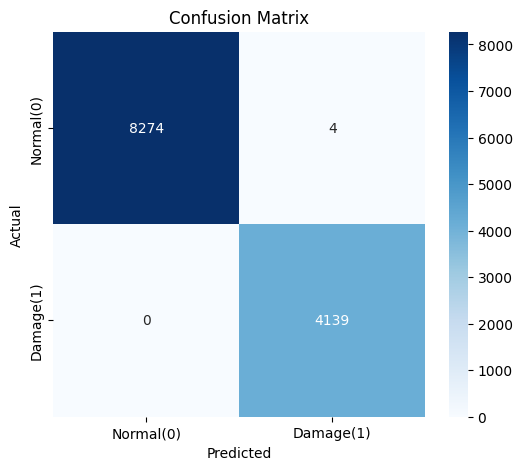

<Figure size 1000x800 with 0 Axes>

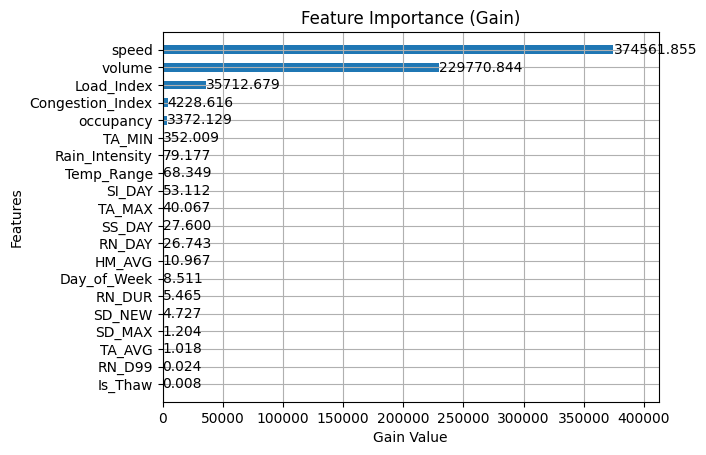

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, plot_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 학습에 사용할 변수(X)와 정답(y) 정의
cols_to_drop = [
    # 1. 정답 컬럼
    'target',

    # 2. 날짜/시간 원본
    'DATE', 'YEAR', 'MONTH', 'DAY',
    'Days_Elapsed',

    # 3. 위치 정보
    'Lat', 'Lon',
    '관할기관', '행정구역', 'District',

    # 4. 단순 식별자/인덱스
    'nearest_vds_id',
    'nearest_vds_index',

    # 5. 혹시 남아있을 수 있는 불필요 텍스트 데이터
    '파손종류', '처리상태', '도로종류', '노선', '방향'
]

# 실제 존재하는 컬럼만 삭제
existing_drop = [c for c in cols_to_drop if c in df_train.columns]
X = df_train.drop(columns=existing_drop, errors='ignore')

# 수치형 데이터만 사용
X = X.select_dtypes(include=['number'])
y = df_train['target']

print(f"🚀 최종 학습 변수 개수: {len(X.columns)}개")
print(f"📋 변수 목록: {X.columns.tolist()}")


# 2. Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")


# 3. LightGBM 모델 학습
print("\n🤖 LightGBM 모델 학습 시작...")

lgbm_model = LGBMClassifier(
    n_estimators=500,       # 나무의 개수 (충분히)
    learning_rate=0.05,     # 학습률 (섬세하게)
    max_depth=10,           # 너무 깊지 않게 (과적합 방지)
    num_leaves=64,          # 리프 노드 수
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
print("✅ 학습 완료!")


# 4. 성능 평가
y_pred = lgbm_model.predict(X_test)

print("\n📊 [모델 성능 평가 리포트]")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal(0)', 'Damage(1)'],
            yticklabels=['Normal(0)', 'Damage(1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 5. 변수 중요도 (Feature Importance)
plt.figure(figsize=(10, 8))

plot_importance(lgbm_model, max_num_features=20, height=0.5, importance_type='gain', title='Feature Importance (Gain)', xlabel='Gain Value')
plt.show()

예측 대상 데이터 개수: 1000개
사용 변수 개수: 25개 (학습 데이터와 동일)

=== 📊 최종 예측 결과 분석 ===
총 데이터: 1000개 (전부 실제 발생지점)
🚨 위험 예측 성공(True Positive): 985개
❌ 위험 예측 실패(False Negative): 15개
🛡️ 재현율 (Recall): 98.50%
------------------------------
평균 위험 확률: 98.41%
최소 위험 확률: 0.00%
최대 위험 확률: 100.00%


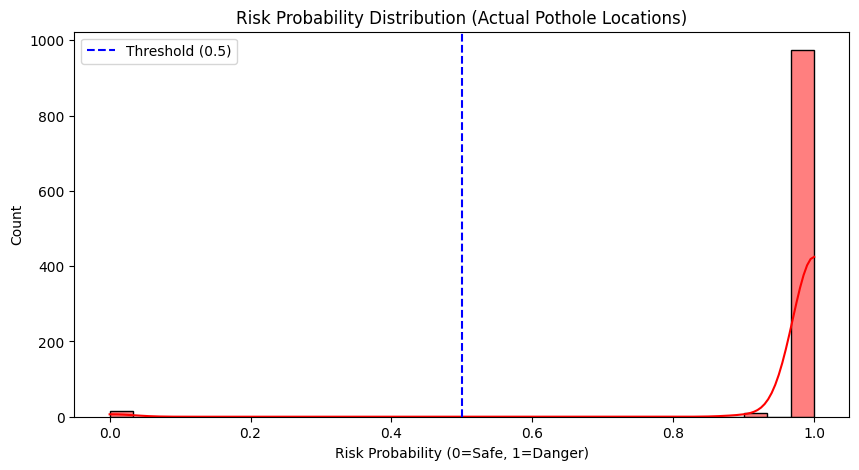

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 데이터 준비 (df_feat3)
# ==========================================
# df_feat3가 원본 발생 데이터라고 가정합니다.
target_df = df_feat3.copy()

# 학습 때 썼던 'Target', 'Date', 'Location' 등 불필요 컬럼 제거
# (cols_to_drop은 아까 정의했던 리스트 그대로 사용)
X_real = target_df.drop(columns=cols_to_drop, errors='ignore')

# 수치형만 선택
X_real = X_real.select_dtypes(include=['number'])

# [핵심] 학습 데이터(X_train)와 컬럼 순서/개수 강제 통일
# - 없는 컬럼은 0으로 채우고
# - 더 있는 컬럼은 삭제하고
# - 순서는 X_train과 똑같이 맞춤
if 'X_train' in locals():
    X_real = X_real.reindex(columns=X_train.columns, fill_value=0)
else:
    print("⚠️ 경고: X_train 변수가 없습니다. 컬럼 매칭에 주의하세요.")

print(f"예측 대상 데이터 개수: {len(X_real)}개")
print(f"사용 변수 개수: {len(X_real.columns)}개 (학습 데이터와 동일)")


# ==========================================
# 2. 예측 수행 (Predict)
# ==========================================
# 확률값 예측 (0~1 사이 실수)
pred_probs = lgbm_model.predict_proba(X_real)[:, 1]

# 결과 저장
df_result = df_feat3.copy()
df_result['Risk_Probability'] = pred_probs
df_result['Predicted_Label'] = (pred_probs >= 0.5).astype(int) # 0.5 기준

# ==========================================
# 3. 결과 분석
# ==========================================
# (1) 통계 요약
print("\n=== 📊 최종 예측 결과 분석 ===")
print(f"총 데이터: {len(df_result)}개 (전부 실제 발생지점)")
print(f"🚨 위험 예측 성공(True Positive): {df_result['Predicted_Label'].sum()}개")
print(f"❌ 위험 예측 실패(False Negative): {len(df_result) - df_result['Predicted_Label'].sum()}개")
print(f"🛡️ 재현율 (Recall): {df_result['Predicted_Label'].mean() * 100:.2f}%")

print("-" * 30)
print(f"평균 위험 확률: {df_result['Risk_Probability'].mean()*100:.2f}%")
print(f"최소 위험 확률: {df_result['Risk_Probability'].min()*100:.2f}%")
print(f"최대 위험 확률: {df_result['Risk_Probability'].max()*100:.2f}%")

# (2) 확률 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(df_result['Risk_Probability'], bins=30, kde=True, color='red')
plt.axvline(0.5, color='blue', linestyle='--', label='Threshold (0.5)')
plt.title('Risk Probability Distribution (Actual Pothole Locations)')
plt.xlabel('Risk Probability (0=Safe, 1=Danger)')
plt.ylabel('Count')
plt.legend()
plt.show()

### XGBoost

🚀 학습 변수 개수: 25개

🔥 XGBoost 모델 학습 시작...
✅ 학습 완료!

📊 [XGBoost 모델 성능 평가]
정확도(Accuracy): 0.9981
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8278
           1       0.99      1.00      1.00      4139

    accuracy                           1.00     12417
   macro avg       1.00      1.00      1.00     12417
weighted avg       1.00      1.00      1.00     12417



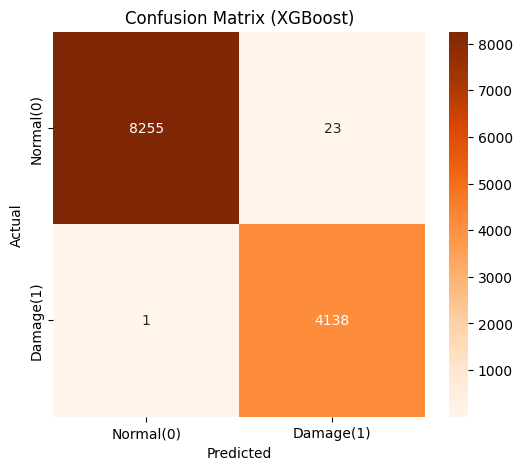

<Figure size 1000x800 with 0 Axes>

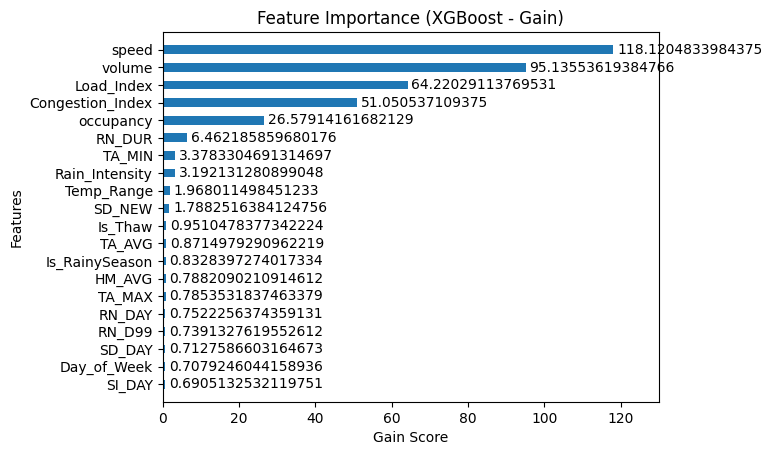

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier, plot_importance

# 1. 데이터 준비
cols_to_drop = [
    'target',
    'DATE', 'YEAR', 'MONTH', 'DAY',
    'Days_Elapsed',
    'Lat', 'Lon', '관할기관', '행정구역', 'District',
    'nearest_vds_id', 'nearest_vds_index',
    '파손종류', '처리상태', '도로종류', '노선', '방향'
]

existing_drop = [c for c in cols_to_drop if c in df_train.columns]
X = df_train.drop(columns=existing_drop, errors='ignore')

X = X.select_dtypes(include=['number'])
y = df_train['target']

print(f"🚀 학습 변수 개수: {len(X.columns)}개")


# 2. Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 3. XGBoost 모델 학습
print("\n🔥 XGBoost 모델 학습 시작...")

# XGBClassifier 정의
xgb_model = XGBClassifier(
    n_estimators=500,       # 나무 개수
    learning_rate=0.05,     # 학습률
    max_depth=10,           # 깊이
    random_state=42,
    n_jobs=-1,              # CPU 병렬 처리
    tree_method='hist',     # 히스토그램 기반 (속도 빠름, LightGBM과 유사 방식)
    importance_type='gain'  # 변수 중요도 기준 (정보 이득)
)

xgb_model.fit(X_train, y_train)
print("✅ 학습 완료!")


# 4. 성능 평가
y_pred = xgb_model.predict(X_test)

print("\n📊 [XGBoost 모델 성능 평가]")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # XGBoost는 주황색 테마로 구분
            xticklabels=['Normal(0)', 'Damage(1)'],
            yticklabels=['Normal(0)', 'Damage(1)'])
plt.title('Confusion Matrix (XGBoost)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# 5. 변수 중요도 (Feature Importance)
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, height=0.5, importance_type='gain',
                title='Feature Importance (XGBoost - Gain)', xlabel='Gain Score', grid=False)
plt.show()

## 결과 시각화

In [ ]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# ---------------------------------------------------------
# 1. 시각화용 데이터 다시 만들기 (원본 정보 + 예측 결과 병합)
# ---------------------------------------------------------
# df_feat3: 원본 데이터 (District, Lat, Lon, DATE 등이 다 살아있음)
# pred_probs_xgb: 아까 XGBoost로 예측한 확률값 (변수에 저장되어 있다고 가정)

# 만약 pred_probs_xgb 변수가 날아갔다면 다시 예측
if 'pred_probs_xgb' not in locals():
    # 학습 때와 동일한 컬럼으로 X_real 준비
    X_real = df_feat3.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include=['number'])
    # 학습 데이터 컬럼 순서와 맞춤 (매우 중요)
    X_real = X_real.reindex(columns=X_train.columns, fill_value=0)
    pred_probs_xgb = xgb_model.predict_proba(X_real)[:, 1]

# [핵심] 원본 데이터(df_feat3)를 복사해서 베이스로 사용
map_data = df_feat3.copy()

# 여기에 예측 결과 추가
map_data['Risk_Probability'] = pred_probs_xgb
map_data['Predicted_Label'] = (pred_probs_xgb >= 0.5).astype(int)

print("데이터 준비 완료!")
print("컬럼 확인:", map_data.columns.tolist()) # 여기에 District가 있어야 함

# ---------------------------------------------------------
# 2. 지도 시각화 (수정된 map_data 사용)
# ---------------------------------------------------------
# 지도 중심 설정
center_lat = map_data['Lat'].mean()
center_lon = map_data['Lon'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# 마커 그룹 생성
risk_group = folium.FeatureGroup(name="🚨 위험 예측 성공 (True Positive)")
miss_group = folium.FeatureGroup(name="❌ 놓친 지점 (False Negative)")

# 지도에 마커 추가
for idx, row in map_data.iterrows():
    # District가 없는 경우 대비 (안전장치)
    district_name = row['District'] if 'District' in row else "알수없음"

    # 팝업 정보
    popup_html = f"""
    <div style="width:200px">
        <b>지역:</b> {district_name}<br>
        <b>날짜:</b> {row['DATE']}<br>
        <b>위험확률:</b> {row['Risk_Probability']*100:.2f}%<br>
        <hr>
        <b>속도:</b> {row['speed']:.1f} km/h<br>
        <b>교통량:</b> {row['volume']:.1f}<br>
        <b>강수:</b> {row['RN_DAY']} mm
    </div>
    """

    # 색상 및 그룹 결정
    if row['Predicted_Label'] == 1:
        # 위험하다고 예측함 (빨강)
        color = 'red'
        folium.CircleMarker(
            location=[row['Lat'], row['Lon']],
            radius=5, color=color, fill=True, fill_color=color, fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(risk_group)
    else:
        # 안전하다고 예측함 (파랑 - 놓친 것)
        color = 'blue'
        folium.CircleMarker(
            location=[row['Lat'], row['Lon']],
            radius=7, color=color, fill=True, fill_color=color, fill_opacity=0.9,
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(miss_group)

# 레이어 컨트롤 추가
risk_group.add_to(m)
miss_group.add_to(m)
folium.LayerControl().add_to(m)

# 저장 및 출력
m.save('Final_Pothole_Prediction_Map.html')
print("🗺️ 지도가 생성되었습니다.")
m

데이터 준비 완료!
컬럼 확인: ['Unnamed: 0', 'Lat', 'Lon', 'YEAR', 'MONTH', 'DAY', 'DATE', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'nearest_vds_index', 'speed', 'volume', 'occupancy', '관할기관', '행정구역', 'Season', 'Is_Thaw', 'Is_RainySeason', 'Day_of_Week', 'Is_Weekend', 'Days_Elapsed', 'Temp_Range', 'Is_Freeze_Thaw', 'Rain_Intensity', 'Congestion_Index', 'Load_Index', 'Is_Congested', 'Risk_Probability', 'Predicted_Label']
🗺️ 지도가 생성되었습니다.
